# This notebook computes the curve number map of the entire NYS based on hydrologic soil goup and land use data
##### Author: Omid Emamjomehzadeh (https://www.omidemam.com/)
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [1]:
# Import libraries
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.io import MemoryFile
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap
from rasterio.plot import show
from rasterio.mask import mask
import rasterio.mask
from osgeo import gdal
import numpy as np
import matplotlib.colors as mcolors
import matplotlib
from matplotlib.lines import Line2D
from tqdm import tqdm
import glob
import os
from PIL import Image
from datetime import datetime
import watermark
import re

#### Visualize NYS's hydrologic soil groups 


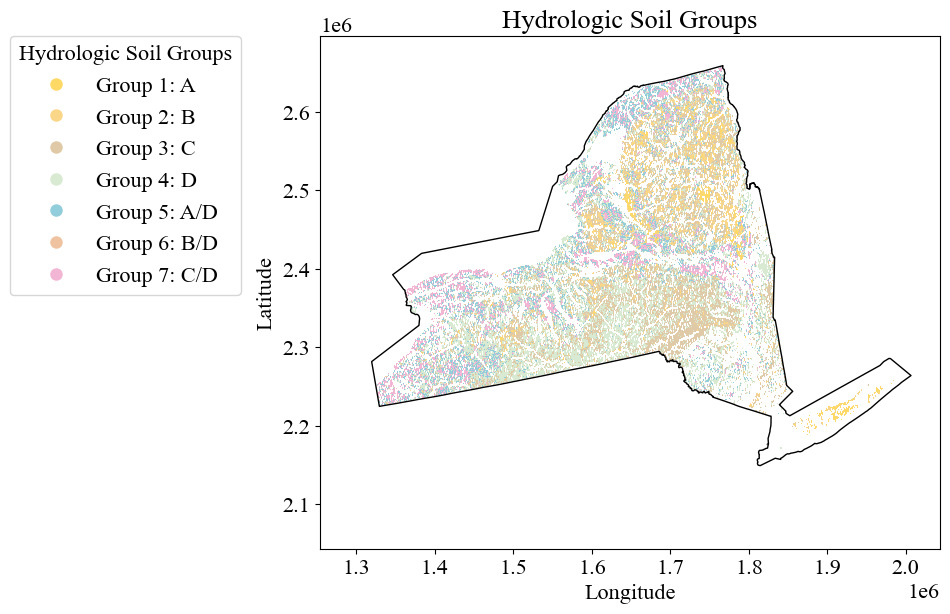

CPU times: total: 34.7 s
Wall time: 37.1 s


In [2]:
%%time

# Set global font properties
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 16

# File paths
hydrologic_soil_path = r"D:\culvert repo\data\initial layers\hydrologic_soil_group_5070.tif"
state_path = r"D:\culvert repo\data\initial layers\state_5070.shp"

# Load the raster file
with rasterio.open(hydrologic_soil_path) as src:
    raster = src.read(1)
    raster_meta = src.meta
    raster_crs = src.crs
    transform = src.transform
    nodata = src.nodata

# Mask NoData values
raster = np.ma.masked_equal(raster, nodata)

# Load the shapefile
shapefile = gpd.read_file(state_path)

# Reproject shapefile to match the raster CRS
shapefile = shapefile.to_crs(raster_crs)

# Define hydrologic soil groups and corresponding colors
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}
colors = {
    1: '#ffd966',
    2: '#fad689',
    3: '#e0c9a6',
    4: '#d9ead3',
    5: '#92cddc',
    6: '#f0c3a0',
    7: '#f2b5d4'
}

# Create a colormap
cmap = mcolors.ListedColormap([colors[key] for key in colors.keys()])
bounds = np.arange(1, len(colors) + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# Plot raster
show(raster, transform=transform, ax=ax, cmap=cmap, norm=norm)

# Plot shapefile
shapefile.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Define custom legend handles and labels
legend_handles = []
legend_labels = []
for key, value in colors.items():
    marker = Line2D([0], [0], marker='o', color='w', markerfacecolor=value, markersize=10)
    legend_handles.append(marker)
    if key in soil_groups:
        legend_labels.append(f'Group {key}: {soil_groups[key]}')

# Add legend with custom handles and labels
plt.legend(handles=legend_handles, labels=legend_labels, title='Hydrologic Soil Groups', loc='upper left', bbox_to_anchor=(-0.5, 1), borderaxespad=0.)

# Hide x and y axis numbers
plt.title("Hydrologic Soil Groups")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig(fr'D:\culvert repo\Results\Figures\NYS_HSG_map.png', dpi=300, bbox_inches='tight')
plt.show()

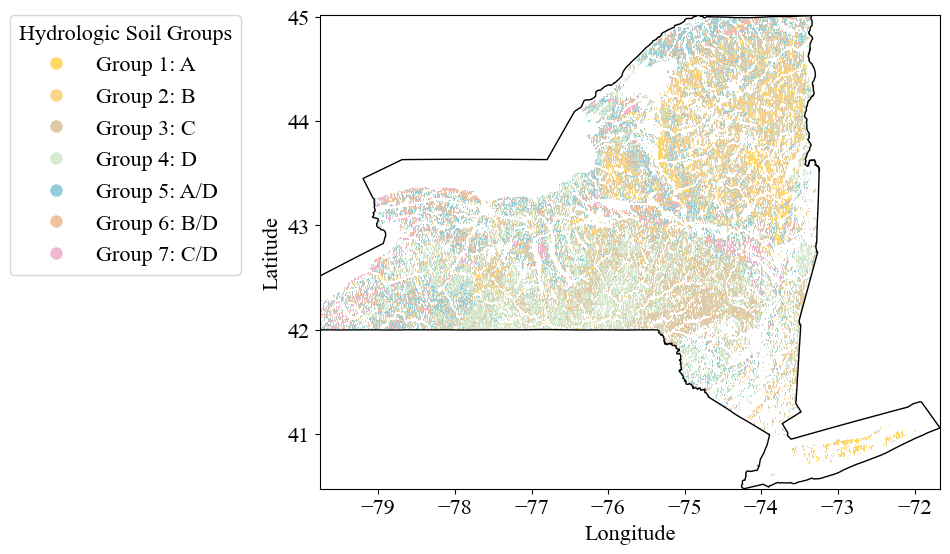

CPU times: total: 38.6 s
Wall time: 40.5 s


In [3]:
%%time
# Set font
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 16

# File paths
hydrologic_soil_path = r"D:\culvert repo\data\initial layers\hydrologic_soil_group_5070.tif"
state_path = r"D:\culvert repo\data\initial layers\state_5070.shp"

# Load and reproject state shapefile to EPSG:4326
shapefile = gpd.read_file(state_path).to_crs(epsg=4326)
geoms = shapefile.geometry.values  # For clipping

# Load the raster and reproject to EPSG:4326 using an in-memory file
with rasterio.open(hydrologic_soil_path) as src:
    nodata = src.nodata
    dst_crs = 'EPSG:4326'
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)

    dst_meta = src.meta.copy()
    dst_meta.update({
        'crs': dst_crs,
        'transform': dst_transform,
        'width': dst_width,
        'height': dst_height
    })

    with MemoryFile() as memfile:
        with memfile.open(**dst_meta) as dst:
            reproject(
                source=src.read(1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )
            # Clip the reprojected raster to NY state shape
            clipped_raster, clipped_transform = mask(dst, geoms, crop=True)
            raster = np.ma.masked_equal(clipped_raster[0], nodata)
            transform = clipped_transform

# Define hydrologic soil groups and colors
soil_groups = {
    1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'A/D', 6: 'B/D', 7: 'C/D'
}
colors = {
    1: '#ffd966', 2: '#fad689', 3: '#e0c9a6', 4: '#d9ead3',
    5: '#92cddc', 6: '#f0c3a0', 7: '#f2b5d4'
}

# Create color map
cmap = mcolors.ListedColormap([colors[k] for k in sorted(colors.keys())])
bounds = np.arange(1, len(colors) + 2) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
show(raster, transform=transform, ax=ax, cmap=cmap, norm=norm)
shapefile.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Custom legend
legend_handles = []
legend_labels = []
for k in sorted(colors.keys()):
    handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[k], markersize=10)
    legend_handles.append(handle)
    legend_labels.append(f'Group {k}: {soil_groups[k]}')

ax.legend(handles=legend_handles, labels=legend_labels, title='Hydrologic Soil Groups',
          loc='upper left', bbox_to_anchor=(-0.5, 1), borderaxespad=0.)

# Add labels and title
#ax.set_title("Hydrologic Soil Groups of New York State")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Save
plt.savefig(r'D:\culvert repo\Results\Figures\NYS_HSG_map.png', dpi=300, bbox_inches='tight')
plt.show()


#### Visualize NYS's National Land Cover


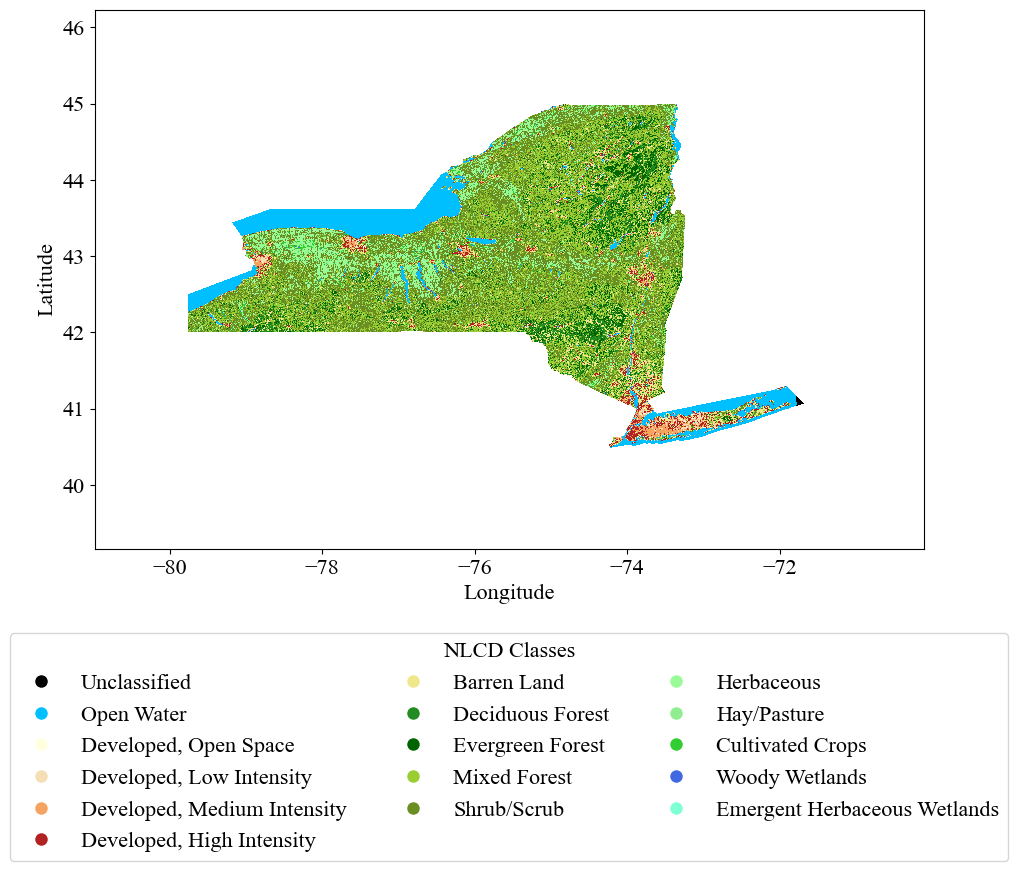

In [11]:
# Set global font properties
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 16
# NLCD raster path
nlcd_file = r'D:\culvert repo\data\initial layers\NLCD_2021_5070.tif'
# Define custom colors for each class
custom_colors = {
    0: 'black',                    # Unclassified
    11: 'deepskyblue',             # Open Water
    21: 'lightyellow',             # Developed, Open Space
    22: 'wheat',                   # Developed, Low Intensity
    23: 'sandybrown',             # Developed, Medium Intensity
    24: 'firebrick',               # Developed, High Intensity
    31: 'khaki',                   # Barren Land
    41: 'forestgreen',             # Deciduous Forest
    42: 'darkgreen',               # Evergreen Forest
    43: 'yellowgreen',             # Mixed Forest
    52: 'olivedrab',               # Shrub/Scrub
    71: 'palegreen',               # Herbaceous
    81: 'lightgreen',             # Hay/Pasture
    82: 'limegreen',               # Cultivated Crops
    90: 'royalblue',               # Woody Wetlands
    95: 'aquamarine'              # Emergent Herbaceous Wetlands
}
# Sorted keys for consistent color mapping
sorted_keys = sorted(custom_colors.keys())
cmap = mcolors.ListedColormap([custom_colors[k] for k in sorted_keys])
bounds = np.array(sorted_keys + [max(sorted_keys) + 1]) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)
# Reproject the raster to EPSG:4326
with rasterio.open(nlcd_file) as src:
    nodata_val = -128
    dst_crs = 'EPSG:4326'
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)

    dst_meta = src.meta.copy()
    dst_meta.update({
        'crs': dst_crs,
        'transform': dst_transform,
        'width': dst_width,
        'height': dst_height
    })
    with MemoryFile() as memfile:
        with memfile.open(**dst_meta) as dst:
            reproject(
                source=src.read(1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )
            reprojected_data = dst.read(1)
            reprojected_data = np.ma.masked_where(reprojected_data == nodata_val, reprojected_data)
# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
img = ax.imshow(reprojected_data, cmap=cmap, norm=norm, extent=[
    dst_transform[2],
    dst_transform[2] + dst_transform[0] * dst_width,
    dst_transform[5] + dst_transform[4] * dst_height,
    dst_transform[5]
])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
#ax.set_title("NLCD 2021 Land Cover (EPSG:4326)")
# Custom legend
legend_labels = [
    'Unclassified', 'Open Water', 'Developed, Open Space', 'Developed, Low Intensity',
    'Developed, Medium Intensity', 'Developed, High Intensity', 'Barren Land',
    'Deciduous Forest', 'Evergreen Forest', 'Mixed Forest', 'Shrub/Scrub',
    'Herbaceous', 'Hay/Pasture', 'Cultivated Crops',
    'Woody Wetlands', 'Emergent Herbaceous Wetlands'
]
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_colors[k], markersize=10)
    for k in sorted_keys
]
ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    title='NLCD Classes',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.6),
    borderaxespad=0.5,
    ncol=3,
    frameon=True
)
# Save and show
plt.savefig(r'D:\culvert repo\Results\Figures\NLCD_2021_map.png', dpi=300, bbox_inches='tight')
plt.show()

#### Calculat the CN

In [ ]:
%%time
# compute the CN raster 
# Function to calculate CN based on NLCD land use and HSG
# 'A', 'B', 'C', and ''D' CN values are obtained from (
#https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/gis-tutorials-and-guides/creating-a-curve-number-grid-and-computing-subbasin-average-
#curve-number-values)
def calculate_cn(nlcd_value, hsg):
    nlcd_to_cn = {
         11: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},
        21: {'A': 72, 'B': 82, 'C': 87, 'D': 89, 'A/D': (72 + 89) / 2, 'B/D': (82 + 89) / 2, 'C/D': (87 + 89) / 2},
        22: {'A': 77, 'B': 85, 'C': 90, 'D': 92, 'A/D': (77 + 92) / 2, 'B/D': (85 + 92) / 2, 'C/D': (90 + 92) / 2},
        23: {'A': 81, 'B': 88, 'C': 91, 'D': 93, 'A/D': (81 + 93) / 2, 'B/D': (88 + 93) / 2, 'C/D': (91 + 93) / 2},
        24: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},
        31: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},
        41: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},
        42: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},
        43: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},
        52: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},
        71: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},
        81: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},
        82: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},
        90: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},
        95: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}
    }
    
    if nlcd_value in nlcd_to_cn and hsg in nlcd_to_cn[nlcd_value]:
        return nlcd_to_cn[nlcd_value][hsg]
    else:
        return None

# Define hydrologic soil groups and corresponding colors
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

# Load NLCD and HSG raster data
with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
    nlcd_data = nlcd_src.read(1)
    hsg_data = hsg_src.read(1)
    
    # Mask NoData values
    nlcd_data = np.ma.masked_where(nlcd_data == -128, nlcd_data)
    hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)
    
    # Initialize CN map
    cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)
    
    # Iterate through each row with progress bar
    for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
        for j in range(nlcd_data.shape[1]):
            if nlcd_data.mask[i, j]:
                continue  # Skip masked values
            
            nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing
            
            # Waters are masked in HSG map this way we will have the CN value
            if nlcd_value==11:
                cn_value=98
                cn_map[i, j] = cn_value
                
            if nlcd_value==95:
                cn_value=98
                cn_map[i, j] = cn_value
            else:
                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)
                
                # Check if the HSG value is masked
                if np.ma.is_masked(hsg_data[hsg_row, hsg_col]):
                    continue  # Skip masked HSG values
    
                # Get the HSG value from the corresponding HSG pixel
                hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing
    
                # Convert hsg_value to the corresponding letter
                if hsg_value in soil_groups:
                    hsg_type = soil_groups[hsg_value]
                else:
                    continue
        
                # Get NLCD class and HSG
                if hsg_value in soil_groups:
                    cn_value = calculate_cn(nlcd_value, hsg_type)
                    
                    if cn_value is not None:
                        cn_map[i, j] = cn_value
                        
# Save the CN map as a new TIFF file
cn_map_path = r'D:\culvert repo\Results\CN\CN_Map_2021.tif'

# Use metadata from the NLCD file
meta = nlcd_src.meta.copy()
meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 0
})

with rasterio.open(cn_map_path, 'w', **meta) as dst:
    dst.write(cn_map, 1)

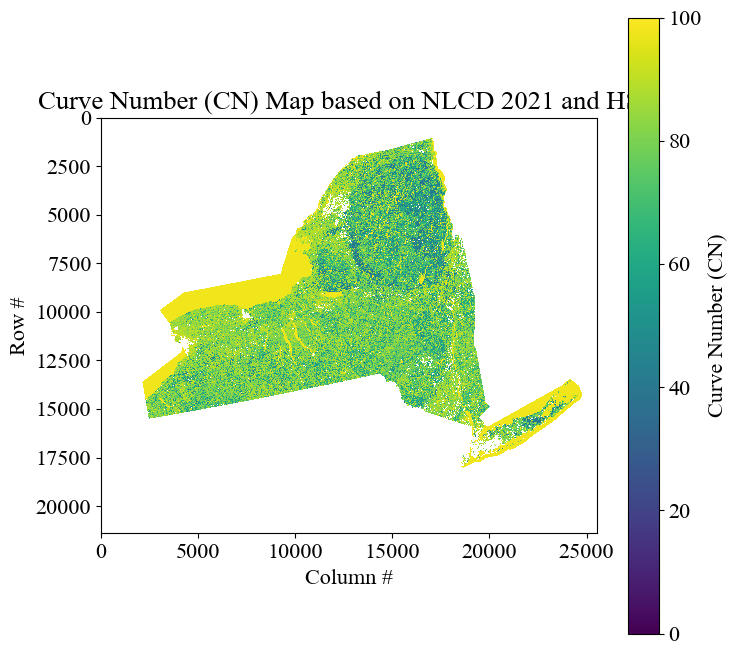

CPU times: total: 25.8 s
Wall time: 26.4 s


In [5]:
%%time
# Nodata value
no_data_value = 0
# Masking NoData values
masked_cn_map = np.ma.masked_where(cn_map == no_data_value, cn_map)
# Plotting the CN map
plt.figure(figsize=(8, 8))
plt.imshow(masked_cn_map, cmap='viridis', vmin=0, vmax=100, interpolation='nearest')
plt.colorbar(label='Curve Number (CN)')
plt.title('Curve Number (CN) Map based on NLCD 2021 and HSG')
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.grid(False)
plt.savefig(fr'D:\culvert repo\Results\Figures\CN_map.png', dpi=300, bbox_inches='tight')
plt.show()

#### Calulate dry and wet nlcd_to_cn dictionaries


In [6]:
# 'A', 'B', 'C', and ''D' CN values are obtained from (https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/gis-tutorials-and-guides/
#creating-a-curve-number-grid-and-computing-subbasin-average-curve-number-values)
nlcd_to_cn = {
    11: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},
        21: {'A': 72, 'B': 82, 'C': 87, 'D': 89, 'A/D': (72 + 89) / 2, 'B/D': (82 + 89) / 2, 'C/D': (87 + 89) / 2},
        22: {'A': 77, 'B': 85, 'C': 90, 'D': 92, 'A/D': (77 + 92) / 2, 'B/D': (85 + 92) / 2, 'C/D': (90 + 92) / 2},
        23: {'A': 81, 'B': 88, 'C': 91, 'D': 93, 'A/D': (81 + 93) / 2, 'B/D': (88 + 93) / 2, 'C/D': (91 + 93) / 2},
        24: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},
        31: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},
        41: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},
        42: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},
        43: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},
        52: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},
        71: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},
        81: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},
        82: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},
        90: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},
        95: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}
}

# Dry and wet modification factors from Table 5.2
dry_factors = {
    10: 0.40,
    20: 0.45,
    30: 0.50,
    40: 0.55,
    50: 0.62,
    60: 0.67,
    70: 0.73,
    80: 0.79,
    90: 0.87,
    100: 1.00
}

wet_factors = {
    10: 2.22,
    20: 1.85,
    30: 1.67,
    40: 1.50,
    50: 1.40,
    60: 1.30,
    70: 1.21,
    80: 1.14,
    90: 1.07,
    100: 1.00
}

nlcd_to_cn_dry = {}
nlcd_to_cn_wet = {}

# Calculate dry and wet CN values for each NLCD class and each type ('A', 'B', 'C', 'D', 'A/D', 'B/D', 'C/D')
for key, value in nlcd_to_cn.items():
    for type_key in ['A', 'B', 'C', 'D', 'A/D', 'B/D', 'C/D']:
        CN = value[type_key]
        
        # Calculate dry CN
        lower_dry_CN = max(filter(lambda x: x <= CN, dry_factors))
        upper_dry_CN = min(filter(lambda x: x >= CN, dry_factors))
        
        if lower_dry_CN == upper_dry_CN:
            CN_dry = dry_factors.get(lower_dry_CN, 1.0) * CN  # Default factor is 1.0 if CN not found
        else:
            # Perform linear interpolation between lower and upper factors
            lower_dry_factor = dry_factors.get(lower_dry_CN, 1.0)
            upper_dry_factor = dry_factors.get(upper_dry_CN, 1.0)
            CN_dry = (lower_dry_factor + (upper_dry_factor - lower_dry_factor) * (CN - lower_dry_CN) / (upper_dry_CN - lower_dry_CN)) * CN
        
        # Calculate wet CN
        lower_wet_CN = max(filter(lambda x: x <= CN, wet_factors))
        upper_wet_CN = min(filter(lambda x: x >= CN, wet_factors))
        
        if lower_wet_CN == upper_wet_CN:
            CN_wet = wet_factors.get(lower_wet_CN, 1.0) * CN  # Default factor is 1.0 if CN not found
        else:
            # Perform linear interpolation between lower and upper factors
            lower_wet_factor = wet_factors.get(lower_wet_CN, 1.0)
            upper_wet_factor = wet_factors.get(upper_wet_CN, 1.0)
            CN_wet = (lower_wet_factor + (upper_wet_factor - lower_wet_factor) * (CN - lower_wet_CN) / (upper_wet_CN - lower_wet_CN)) * CN
        
        # Store the dry and wet CN values in the dictionaries
        if key not in nlcd_to_cn_dry:
            nlcd_to_cn_dry[key] = {}
        if key not in nlcd_to_cn_wet:
            nlcd_to_cn_wet[key] = {}
        
        nlcd_to_cn_dry[key][type_key] = CN_dry
        nlcd_to_cn_wet[key][type_key] = CN_wet

print("NLCD to CN Dry:")
print(nlcd_to_cn_dry)
print("\nNLCD to CN Wet:")
print(nlcd_to_cn_wet)

NLCD to CN Dry:
{11: {'A': 95.452, 'B': 95.452, 'C': 95.452, 'D': 95.452, 'A/D': 95.452, 'B/D': 95.452, 'C/D': 95.452}, 21: {'A': 53.424, 'B': 66.092, 'C': 73.602, 'D': 76.718, 'A/D': 63.917, 'B/D': 71.307, 'C/D': 75.152}, 22: {'A': 59.444, 'B': 70.55000000000001, 'C': 78.3, 'D': 82.432, 'A/D': 69.79700000000001, 'B/D': 75.93299999999999, 'C/D': 80.353}, 23: {'A': 64.638, 'B': 75.152, 'C': 80.353, 'D': 84.537, 'A/D': 73.602, 'B/D': 79.32325, 'C/D': 82.432}, 24: {'A': 95.452, 'B': 95.452, 'C': 95.452, 'D': 95.452, 'A/D': 95.452, 'B/D': 95.452, 'C/D': 95.452}, 31: {'A': 59.444, 'B': 72.068, 'C': 80.353, 'D': 86.668, 'A/D': 71.307, 'B/D': 78.3, 'C/D': 83.48125}, 41: {'A': 26.325, 'B': 46.596, 'C': 59.444, 'D': 67.56200000000001, 'A/D': 44.416000000000004, 'B/D': 56.3965, 'C/D': 63.2}, 42: {'A': 21.329050000000006, 'B': 29.088, 'C': 37.335, 'D': 43.344, 'A/D': 31.919012499999997, 'B/D': 35.93625, 'C/D': 40.2}, 43: {'A': 21.329050000000006, 'B': 29.088, 'C': 37.335, 'D': 43.344, 'A/D': 31.9

In [7]:
%%time
# compute the CN raster for dry conditions
# Function to calculate CN (dry) based on NLCD land use and HSG
def calculate_cn_dry(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_dry and hsg in nlcd_to_cn_dry[nlcd_value]:
        return nlcd_to_cn_dry[nlcd_value][hsg]
    else:
        return None

# Define hydrologic soil groups and corresponding colors
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

# Load NLCD and HSG raster data
with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
    nlcd_data = nlcd_src.read(1)
    hsg_data = hsg_src.read(1)
    
    # Mask NoData values
    nlcd_data = np.ma.masked_where(nlcd_data == -128, nlcd_data)
    hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)
    
    # Initialize CN map
    cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)
    
    # Iterate through each row with progress bar
    for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
        for j in range(nlcd_data.shape[1]):
            if nlcd_data.mask[i, j]:
                continue  # Skip masked values
            
            nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing
            
            # Waters are masked in HSG map this way we will have the CN value
            if nlcd_value==11:
                cn_value=95.452
                cn_map[i, j] = cn_value
            else:
                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)
                
                # Check if the HSG value is masked
                if np.ma.is_masked(hsg_data[hsg_row, hsg_col]):
                    continue  # Skip masked HSG values
    
                # Get the HSG value from the corresponding HSG pixel
                hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing
    
                # Convert hsg_value to the corresponding letter
                if hsg_value in soil_groups:
                    hsg_type = soil_groups[hsg_value]
                else:
                    continue
        
                # Get NLCD class and HSG
                if hsg_value in soil_groups:
                    cn_value = calculate_cn_dry(nlcd_value, hsg_type)
                    
                    if cn_value is not None:
                        cn_map[i, j] = cn_value
                        
# Save the CN map as a new TIFF file
cn_map_path = r'D:\culvert repo\Results\CN\CN_Map_dry_2021.tif'

# Use metadata from the NLCD file
meta = nlcd_src.meta.copy()
meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 0
})
with rasterio.open(cn_map_path, 'w', **meta) as dst:
    dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████| 21407/21407 [2:59:47<00:00,  1.98it/s]


CPU times: total: 2h 55min 24s
Wall time: 3h 5s


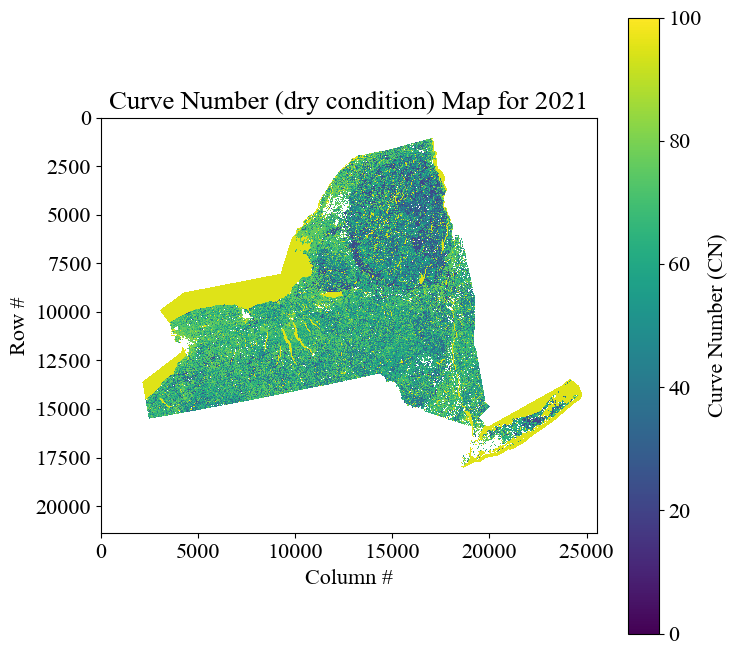

CPU times: total: 29.5 s
Wall time: 30.4 s


In [8]:
%%time
# Plot dry CN 
# Nodata value
no_data_value = 0
# Masking NoData values
masked_cn_map = np.ma.masked_where(cn_map == no_data_value, cn_map)
# Plotting the CN map
plt.figure(figsize=(8, 8))
plt.imshow(masked_cn_map, cmap='viridis', vmin=0, vmax=100, interpolation='nearest')
plt.colorbar(label='Curve Number (CN)')
plt.title('Curve Number (dry condition) Map for 2021',',shrink=0.7)
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.grid(False)
plt.savefig(fr'D:\culvert repo\Results\Figures\CN_dry_map.png', dpi=1000, bbox_inches='tight')
plt.show()

In [9]:
%%time
# Compute the CN raster for wet ASM condition
# Function to calculate CN (wet) based on NLCD land use and HSG
def calculate_cn_wet(nlcd_value, hsg):
    if nlcd_value in nlcd_to_cn_wet and hsg in nlcd_to_cn_wet[nlcd_value]:
        return nlcd_to_cn_wet[nlcd_value][hsg]
    else:
        return None
# Define hydrologic soil groups and corresponding colors
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

# Load NLCD and HSG raster data
with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
    nlcd_data = nlcd_src.read(1)
    hsg_data = hsg_src.read(1)
    
    # Mask NoData values
    nlcd_data = np.ma.masked_where(nlcd_data == -128, nlcd_data)
    hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)
    
    # Initialize CN map
    cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)
    
    # Iterate through each row with progress bar
    for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
        for j in range(nlcd_data.shape[1]):
            if nlcd_data.mask[i, j]:
                continue  # Skip masked values
            
            nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing
            
            # Waters are masked in HSG map this way we will have the CN value
            if nlcd_value==11:
                cn_value=99.372
                cn_map[i, j] = cn_value
            else:
                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)
                
                # Check if the HSG value is masked
                if np.ma.is_masked(hsg_data[hsg_row, hsg_col]):
                    continue  # Skip masked HSG values
    
                # Get the HSG value from the corresponding HSG pixel
                hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing
    
                # Convert hsg_value to the corresponding letter
                if hsg_value in soil_groups:
                    hsg_type = soil_groups[hsg_value]
                else:
                    continue
                # Get NLCD class and HSG
                if hsg_value in soil_groups:
                    cn_value = calculate_cn_wet(nlcd_value, hsg_type)
                    if cn_value is not None:
                        cn_map[i, j] = cn_value
# Save the CN map as a new TIFF file
cn_map_path = r'D:\culvert repo\Results\CN\CN_Map_wet_2021.tif'
# Use metadata from the NLCD file
meta = nlcd_src.meta.copy()
meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 0
})
with rasterio.open(cn_map_path, 'w', **meta) as dst:
    dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████| 21407/21407 [2:59:17<00:00,  1.99it/s]


CPU times: total: 2h 54min 52s
Wall time: 2h 59min 35s


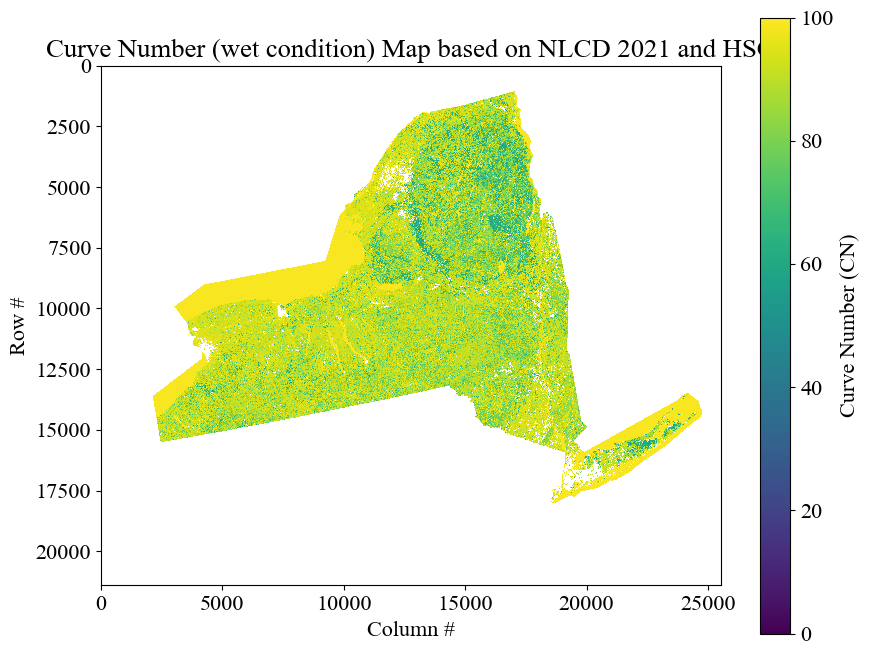

CPU times: total: 31.8 s
Wall time: 32.6 s


In [10]:
%%time
# Plot the CN wet condition
# Nodata value
no_data_value = 0
# Masking NoData values
masked_cn_map = np.ma.masked_where(cn_map == no_data_value, cn_map)
# Plotting the CN map
plt.figure(figsize=(10, 8))
plt.imshow(masked_cn_map, cmap='viridis', vmin=0, vmax=100, interpolation='nearest')
plt.colorbar(label='Curve Number (CN)')
plt.title('Curve Number wet ASM Map based on NLCD 2021',',shrink=0.7)
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.grid(False)
plt.savefig(fr'D:\culvert repo\Results\Figures\CN_wet_map.png', dpi=1000, bbox_inches='tight')
plt.show()

#### Visualize NYS land cover projections

dataset link : https://data.usgs.gov/datacatalog/data/USGS:5b96c2f9e4b0702d0e826f6d

The A1, A1B, B2, and BA climate scenarios are part of the Special Report on Emissions Scenarios (SRES), developed by the Intergovernmental Panel on Climate Change (IPCC) in 2000. These scenarios were used in the Third Assessment Report (TAR) and the Fourth Assessment Report (AR4) of the IPCC to model future climate conditions based on different assumptions about economic growth, population change, and technological development. Here's a brief overview of each:

A1 Scenario\
A1: This scenario describes a future world of very rapid economic growth, a global population that peaks in mid-century and declines thereafter, and the rapid introduction of new and more efficient technologies.\
A1FI (Fossil-Intensive): A1 with a focus on fossil fuels.\
A1B (Balanced): A balance across all energy sources (fossil and non-fossil).\
A1T (Technological): A focus on non-fossil energy sources.\
B2 Scenario\
B2: This scenario describes a world with intermediate levels of economic development, with an emphasis on local solutions to economic, social, and environmental sustainability. Population continues to increase, but at a slower rate than in A1.\
BA Scenario\
BA: This is not an official IPCC scenario. It might be a typo or misinterpretation. The commonly referenced SRES scenarios are A1, A2, B1, and B2.
A1 and B2 are the most different scenarios\

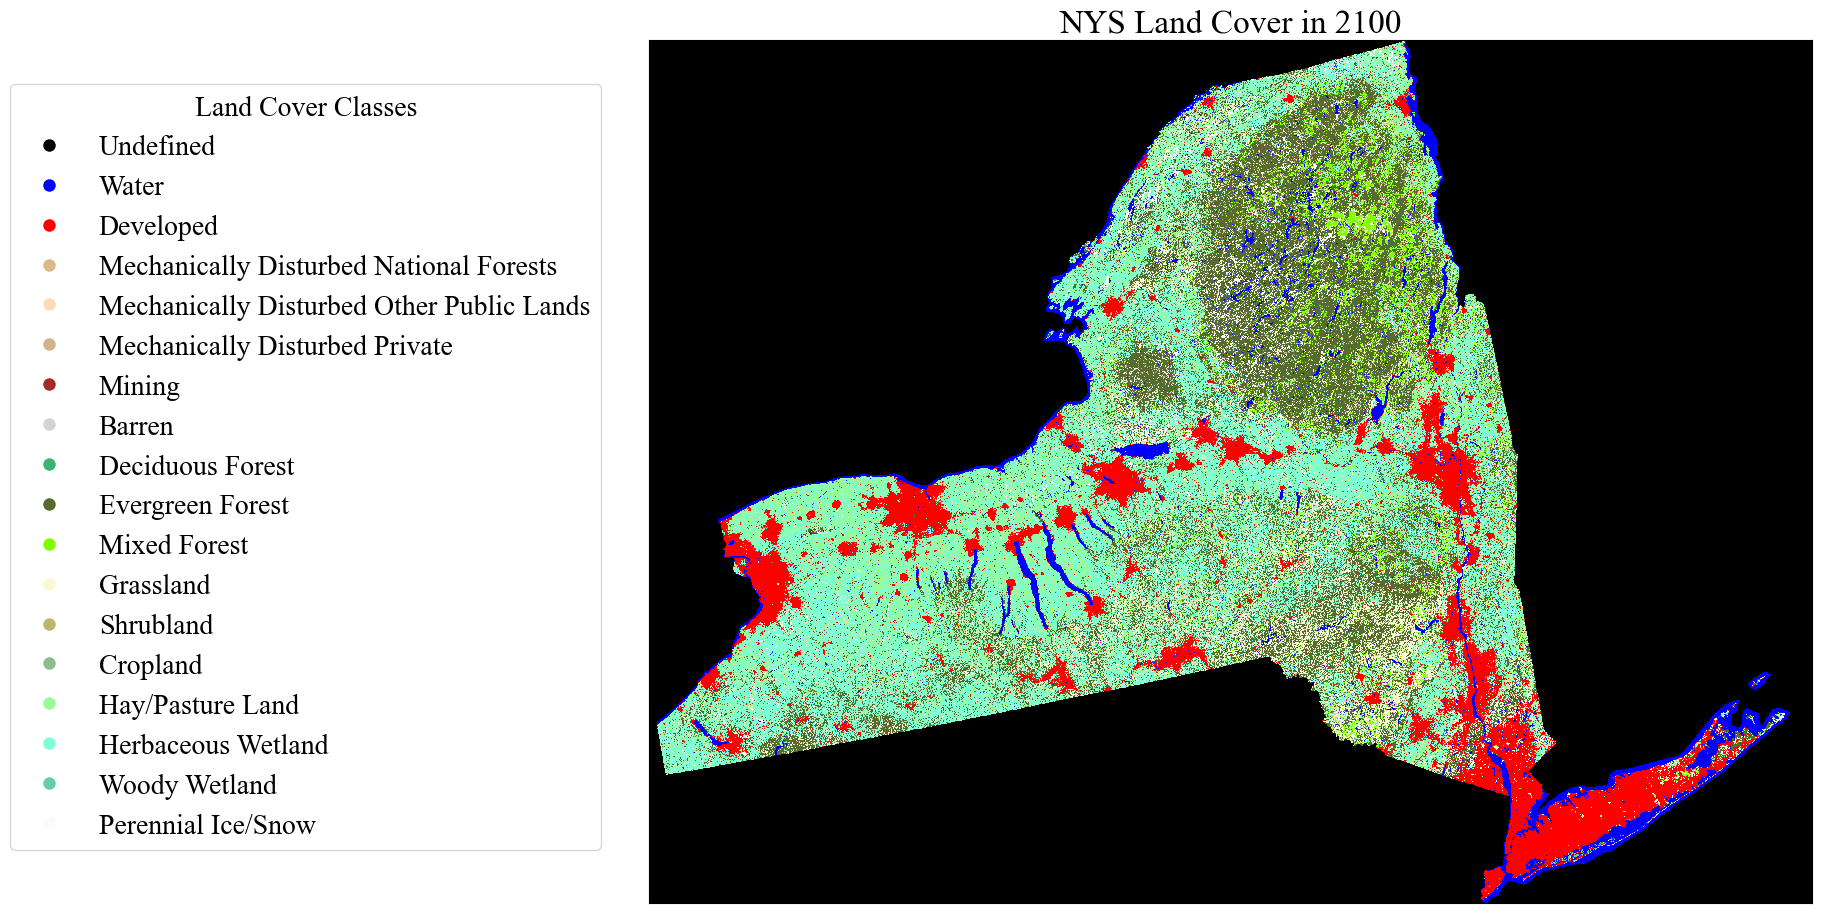

In [36]:
# Set global font properties
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20

# Path to your state shapefile and raster file
raster_file = r"D:\hydrological analysis\data\CN\CONUS_Landcover\CONUS_Landcover_A2\CONUS_A2_y2100.tif"

# Load the state shapefile
state_gdf = gpd.read_file(state_path)

# Open the raster file
with rasterio.open(raster_file) as src:
    # Mask the raster using the state boundary
    out_image, out_transform = rasterio.mask.mask(src, state_gdf.geometry, crop=True)
    out_meta = src.meta.copy()

    # Update the metadata to reflect the new dimensions and transform
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

    # Save the clipped raster to a new file
    clipped_raster_path = r'D:\culvert repo\data\initial layers\CONUS_Landcover\CONUS_Landcover_A2\CONUS_A2_y2100_clipped.tif'
    with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
        dest.write(out_image)
    
    # Mask NoData values
    raster_data = np.ma.masked_where(out_image[0] == src.nodata, out_image[0])

    # Define custom colors for each class
    custom_colors = {
        0: 'black',                # Undefined
        1: 'blue',                 # Water
        2: 'red',                  # Developed
        3: 'burlywood',            # Mechanically Disturbed National Forests
        4: 'peachpuff',            # Mechanically Disturbed Other Public Lands
        5: 'tan',                  # Mechanically Disturbed Private
        6: 'brown',                # Mining
        7: 'lightgray',            # Barren
        8: 'mediumseagreen',       # Deciduous Forest
        9: 'darkolivegreen',       # Evergreen Forest
        10: 'chartreuse',          # Mixed Forest
        11: 'lightgoldenrodyellow',# Grassland
        12: 'darkkhaki',           # Shrubland
        13: 'darkseagreen',        # Cropland
        14: 'palegreen',           # Hay/Pasture Land
        15: 'aquamarine',          # Herbaceous Wetland
        16: 'mediumaquamarine',    # Woody Wetland
        17: 'snow',                # Perennial Ice/Snow
    }

    # Create a colormap based on custom colors
    cmap = mcolors.ListedColormap([custom_colors[key] for key in sorted(custom_colors.keys())])

    # Plotting the raster data with custom colors
    plt.figure(figsize=(15, 15))
    plt.imshow(raster_data, cmap=cmap, interpolation='nearest')
    plt.title('NYS Land Cover in 2100')

    # Create a legend with custom colors and descriptions
    legend_handles = []
    for key, value in custom_colors.items():
        legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=value, markersize=10, label=value))

    # Update legend labels with descriptions
    legend_labels = [
        'Undefined','Water', 'Developed', 'Mechanically Disturbed National Forests', 'Mechanically Disturbed Other Public Lands',
        'Mechanically Disturbed Private', 'Mining', 'Barren', 'Deciduous Forest',
        'Evergreen Forest', 'Mixed Forest', 'Grassland', 'Shrubland', 'Cropland',
        'Hay/Pasture Land', 'Herbaceous Wetland', 'Woody Wetland', 'Perennial Ice/Snow'
    ]

    plt.legend(handles=legend_handles, labels=legend_labels, title='Land Cover Classes', loc='upper left', prop={'size': 20},
               bbox_to_anchor=(-0.55, 0.95), borderaxespad=0.)

    # Remove axis ticks and labels for a cleaner presentation
    plt.xticks([])
    plt.yticks([])
    
    # Save the figure
    plt.savefig(r'D:\culvert repo\Results\Figures\CONUS_A2_2100_map.png', dpi=300, bbox_inches='tight')
    
    # Show plot
    plt.show()

# A2

In [69]:
# Define the directory containing the .tif files
directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\CONUS_Landcover_A2'
tif_files = glob.glob(f'{directory}\\*.tif')

In [ ]:
# Set global font properties
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20

# Path to your state shapefile
state_path = r"D:\culvert repo\data\initial layers\state_5070.shp"

# Load the state shapefile
state_gdf = gpd.read_file(state_path)

# Define the directories
tif_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\CONUS_Landcover_A2'
clipped_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A2'
figure_directory = r'D:\culvert repo\Results\Figures\A2'

# Ensure directories exist
os.makedirs(clipped_directory, exist_ok=True)
os.makedirs(figure_directory, exist_ok=True)

# Get all .tif files in the directory
tif_files = glob.glob(f'{tif_directory}\\*.tif')

# Define custom colors for each class
custom_colors = {
    0: 'black',                # Undefined
    1: 'blue',                 # Water
    2: 'red',                  # Developed
    3: 'burlywood',            # Mechanically Disturbed National Forests
    4: 'peachpuff',            # Mechanically Disturbed Other Public Lands
    5: 'tan',                  # Mechanically Disturbed Private
    6: 'brown',                # Mining
    7: 'lightgray',            # Barren
    8: 'mediumseagreen',       # Deciduous Forest
    9: 'darkolivegreen',       # Evergreen Forest
    10: 'chartreuse',          # Mixed Forest
    11: 'lightgoldenrodyellow',# Grassland
    12: 'darkkhaki',           # Shrubland
    13: 'darkseagreen',        # Cropland
    14: 'palegreen',           # Hay/Pasture Land
    15: 'aquamarine',          # Herbaceous Wetland
    16: 'mediumaquamarine',    # Woody Wetland
    17: 'snow',                # Perennial Ice/Snow
}

# Create a colormap based on custom colors
cmap = mcolors.ListedColormap([custom_colors[key] for key in sorted(custom_colors.keys())])

# Loop through each .tif file in the directory
for i in range(24, len(tif_files), 10):
    raster_file = tif_files[i]    
    filename = os.path.basename(raster_file)
    match = re.match(r'CONUS_(\w+)_y(\d{4})\.tif', filename)
    if match:
        scenario = match.group(1)
        year = match.group(2)
    else:
        scenario = 'Unknown'
        year = 'Unknown'

    # Open the raster file
    with rasterio.open(raster_file) as src:
        # Mask the raster using the state boundary
        out_image, out_transform = rasterio.mask.mask(src, state_gdf.geometry, crop=True)
        out_meta = src.meta.copy()

        # Update the metadata to reflect the new dimensions and transform
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        # Save the clipped raster to a new file
        clipped_raster_filename = os.path.basename(raster_file).replace('.tif', '_clipped.tif')
        clipped_raster_path = os.path.join(clipped_directory, clipped_raster_filename)
        with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
            dest.write(out_image)

        # Mask NoData values
        raster_data = np.ma.masked_where(out_image[0] == src.nodata, out_image[0])

        # Plotting the raster data with custom colors
        plt.figure(figsize=(15, 15))
        plt.imshow(raster_data, cmap=cmap, interpolation='nearest')
        plt.title(f'NYS Land Cover - Scenario: {scenario} Year: {year}')

        # Create a legend with custom colors and descriptions
        legend_handles = []
        for key, value in custom_colors.items():
            legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=value, markersize=10, label=value))

        # Update legend labels with descriptions
        legend_labels = [
            'Undefined', 'Water', 'Developed', 'Mechanically Disturbed National Forests', 'Mechanically Disturbed Other Public Lands',
            'Mechanically Disturbed Private', 'Mining', 'Barren', 'Deciduous Forest',
            'Evergreen Forest', 'Mixed Forest', 'Grassland', 'Shrubland', 'Cropland',
            'Hay/Pasture Land', 'Herbaceous Wetland', 'Woody Wetland', 'Perennial Ice/Snow'
        ]

        plt.legend(handles=legend_handles, labels=legend_labels, title='Land Cover Classes', loc='upper left', prop={'size': 20},
               bbox_to_anchor=(-0.55, 0.95), borderaxespad=0.)

        # Remove axis ticks and labels for a cleaner presentation
        plt.xticks([])
        plt.yticks([])

        # Save the figure
        figure_filename = os.path.basename(raster_file).replace('.tif', '_map.png')
        figure_path = os.path.join(figure_directory, figure_filename)
        plt.savefig(figure_path, dpi=300, bbox_inches='tight')        
        # Show plot
        plt.show()


In [ ]:
# Allow large TIFF files to be processed
Image.MAX_IMAGE_PIXELS = None

# Directory containing the images
image_dir = r'D:\culvert repo\Results\Figures\A2'

# Get list of image files
image_files = sorted([os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith('.png')])

# Create a figure and axis with larger dimensions
fig, ax = plt.subplots(figsize=(25, 15))

# Function to update the frame
def update(frame):
    img = Image.open(image_files[frame])
    img_array = np.array(img)
    ax.clear()  # Clear the previous image
    ax.imshow(img_array, aspect='auto')  # Maintain the aspect ratio
    ax.axis('off')  # Hide axes

    # Set the limits to fit the image
    ax.set_xlim(0, img_array.shape[1])
    ax.set_ylim(img_array.shape[0], 0)  # Invert y-axis to match image orientation

    print(f"Processing frame {frame + 1} of {len(image_files)}")  # Show progress
    return ax

# Create the animation
ani = FuncAnimation(fig, update, frames=len(image_files), interval=350, repeat=True)

# Save the animation
ani.save(os.path.join(image_dir, 'future_landcover_animation_A2.gif'), writer='pillow')

# Display the animation
plt.show()


# A1B

In [ ]:
# Set global font properties
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20

# Load the state shapefile
state_gdf = gpd.read_file(state_path)

# Define the directories
tif_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\CONUS_Landcover_A1B'
clipped_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A1B'
figure_directory = r'D:\culvert repo\Results\Figures\A1B'

# Ensure directories exist
os.makedirs(clipped_directory, exist_ok=True)
os.makedirs(figure_directory, exist_ok=True)

# Get all .tif files in the directory
tif_files = glob.glob(f'{tif_directory}\\*.tif')

# Define custom colors for each class
custom_colors = {
    0: 'black',                # Undefined
    1: 'blue',                 # Water
    2: 'red',                  # Developed
    3: 'burlywood',            # Mechanically Disturbed National Forests
    4: 'peachpuff',            # Mechanically Disturbed Other Public Lands
    5: 'tan',                  # Mechanically Disturbed Private
    6: 'brown',                # Mining
    7: 'lightgray',            # Barren
    8: 'mediumseagreen',       # Deciduous Forest
    9: 'darkolivegreen',       # Evergreen Forest
    10: 'chartreuse',          # Mixed Forest
    11: 'lightgoldenrodyellow',# Grassland
    12: 'darkkhaki',           # Shrubland
    13: 'darkseagreen',        # Cropland
    14: 'palegreen',           # Hay/Pasture Land
    15: 'aquamarine',          # Herbaceous Wetland
    16: 'mediumaquamarine',    # Woody Wetland
    17: 'snow',                # Perennial Ice/Snow
}

# Create a colormap based on custom colors
cmap = mcolors.ListedColormap([custom_colors[key] for key in sorted(custom_colors.keys())])

# Loop through each .tif file in the directory
for i in range(24, len(tif_files), 10):
    raster_file = tif_files[i]      
    filename = os.path.basename(raster_file)
    match = re.match(r'CONUS_(\w+)_y(\d{4})\.tif', filename)
    if match:
        scenario = match.group(1)
        year = match.group(2)
    else:
        scenario = 'Unknown'
        year = 'Unknown'

    # Open the raster file
    with rasterio.open(raster_file) as src:
        # Mask the raster using the state boundary
        out_image, out_transform = rasterio.mask.mask(src, state_gdf.geometry, crop=True)
        out_meta = src.meta.copy()

        # Update the metadata to reflect the new dimensions and transform
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        # Save the clipped raster to a new file
        clipped_raster_filename = os.path.basename(raster_file).replace('.tif', '_clipped.tif')
        clipped_raster_path = os.path.join(clipped_directory, clipped_raster_filename)
        with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
            dest.write(out_image)

        # Mask NoData values
        raster_data = np.ma.masked_where(out_image[0] == src.nodata, out_image[0])

        # Plotting the raster data with custom colors
        plt.figure(figsize=(15, 15))
        plt.imshow(raster_data, cmap=cmap, interpolation='nearest')
        plt.title(f'NYS Land Cover - Scenario: {scenario} Year: {year}')

        # Create a legend with custom colors and descriptions
        legend_handles = []
        for key, value in custom_colors.items():
            legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=value, markersize=10, label=value))

        # Update legend labels with descriptions
        legend_labels = [
            'Undefined', 'Water', 'Developed', 'Mechanically Disturbed National Forests', 'Mechanically Disturbed Other Public Lands',
            'Mechanically Disturbed Private', 'Mining', 'Barren', 'Deciduous Forest',
            'Evergreen Forest', 'Mixed Forest', 'Grassland', 'Shrubland', 'Cropland',
            'Hay/Pasture Land', 'Herbaceous Wetland', 'Woody Wetland', 'Perennial Ice/Snow'
        ]

        plt.legend(handles=legend_handles, labels=legend_labels, title='Land Cover Classes', loc='upper left', prop={'size': 20},
               bbox_to_anchor=(-0.55, 0.95), borderaxespad=0.)

        # Remove axis ticks and labels for a cleaner presentation
        plt.xticks([])
        plt.yticks([])

        # Save the figure
        figure_filename = os.path.basename(raster_file).replace('.tif', '_map.png')
        figure_path = os.path.join(figure_directory, figure_filename)
        plt.savefig(figure_path, dpi=300, bbox_inches='tight')

        # Show plot
        plt.show()


In [ ]:
# Allow large TIFF files to be processed
Image.MAX_IMAGE_PIXELS = None

# Directory containing the images
image_dir = r'D:\culvert repo\Results\Figures\A1B'

# Get list of image files
image_files = sorted([os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith('.png')])

# Create a figure and axis with larger dimensions
fig, ax = plt.subplots(figsize=(25, 15))

# Function to update the frame
def update(frame):
    img = Image.open(image_files[frame])
    img_array = np.array(img)
    ax.clear()  # Clear the previous image
    ax.imshow(img_array, aspect='auto')  # Maintain the aspect ratio
    ax.axis('off')  # Hide axes

    # Set the limits to fit the image
    ax.set_xlim(0, img_array.shape[1])
    ax.set_ylim(img_array.shape[0], 0)  # Invert y-axis to match image orientation

    print(f"Processing frame {frame + 1} of {len(image_files)}")  # Show progress
    return ax

# Create the animation
ani = FuncAnimation(fig, update, frames=len(image_files), interval=350, repeat=True)

# Save the animation
ani.save(os.path.join(image_dir, 'future_landcover_animation_A1B.gif'), writer='pillow')

# Display the animation
plt.show()

# B2

In [ ]:
# Set global font properties
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20


# Load the state shapefile
state_gdf = gpd.read_file(state_path)

# Define the directories
tif_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\CONUS_Landcover_B2'
clipped_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B2'
figure_directory = r'D:\culvert repo\Results\Figures\B2'

# Ensure directories exist
os.makedirs(clipped_directory, exist_ok=True)
os.makedirs(figure_directory, exist_ok=True)

# Get all .tif files in the directory
tif_files = glob.glob(f'{tif_directory}\\*.tif')

# Define custom colors for each class
custom_colors = {
    0: 'black',                # Undefined
    1: 'blue',                 # Water
    2: 'red',                  # Developed
    3: 'burlywood',            # Mechanically Disturbed National Forests
    4: 'peachpuff',            # Mechanically Disturbed Other Public Lands
    5: 'tan',                  # Mechanically Disturbed Private
    6: 'brown',                # Mining
    7: 'lightgray',            # Barren
    8: 'mediumseagreen',       # Deciduous Forest
    9: 'darkolivegreen',       # Evergreen Forest
    10: 'chartreuse',          # Mixed Forest
    11: 'lightgoldenrodyellow',# Grassland
    12: 'darkkhaki',           # Shrubland
    13: 'darkseagreen',        # Cropland
    14: 'palegreen',           # Hay/Pasture Land
    15: 'aquamarine',          # Herbaceous Wetland
    16: 'mediumaquamarine',    # Woody Wetland
    17: 'snow',                # Perennial Ice/Snow
}

# Create a colormap based on custom colors
cmap = mcolors.ListedColormap([custom_colors[key] for key in sorted(custom_colors.keys())])

# Loop through each .tif file in the directory
for i in range(24, len(tif_files), 10):
    raster_file = tif_files[i]       
    filename = os.path.basename(raster_file)
    match = re.match(r'CONUS_(\w+)_y(\d{4})\.tif', filename)
    if match:
        scenario = match.group(1)
        year = match.group(2)
    else:
        scenario = 'Unknown'
        year = 'Unknown'

    # Open the raster file
    with rasterio.open(raster_file) as src:
        # Mask the raster using the state boundary
        out_image, out_transform = rasterio.mask.mask(src, state_gdf.geometry, crop=True)
        out_meta = src.meta.copy()

        # Update the metadata to reflect the new dimensions and transform
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        # Save the clipped raster to a new file
        clipped_raster_filename = os.path.basename(raster_file).replace('.tif', '_clipped.tif')
        clipped_raster_path = os.path.join(clipped_directory, clipped_raster_filename)
        with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
            dest.write(out_image)

        # Mask NoData values
        raster_data = np.ma.masked_where(out_image[0] == src.nodata, out_image[0])

        # Plotting the raster data with custom colors
        plt.figure(figsize=(15, 15))
        plt.imshow(raster_data, cmap=cmap, interpolation='nearest')
        plt.title(f'NYS Land Cover - Scenario: {scenario} Year: {year}')

        # Create a legend with custom colors and descriptions
        legend_handles = []
        for key, value in custom_colors.items():
            legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=value, markersize=10, label=value))

        # Update legend labels with descriptions
        legend_labels = [
            'Undefined', 'Water', 'Developed', 'Mechanically Disturbed National Forests', 'Mechanically Disturbed Other Public Lands',
            'Mechanically Disturbed Private', 'Mining', 'Barren', 'Deciduous Forest',
            'Evergreen Forest', 'Mixed Forest', 'Grassland', 'Shrubland', 'Cropland',
            'Hay/Pasture Land', 'Herbaceous Wetland', 'Woody Wetland', 'Perennial Ice/Snow'
        ]

        plt.legend(handles=legend_handles, labels=legend_labels, title='Land Cover Classes', loc='upper left', prop={'size': 20},
               bbox_to_anchor=(-0.55, 0.95), borderaxespad=0.)

        # Remove axis ticks and labels for a cleaner presentation
        plt.xticks([])
        plt.yticks([])

        # Save the figure
        figure_filename = os.path.basename(raster_file).replace('.tif', '_map.png')
        figure_path = os.path.join(figure_directory, figure_filename)
        plt.savefig(figure_path, dpi=300, bbox_inches='tight')

        # Show plot
        plt.show()

In [ ]:
# Allow large TIFF files to be processed
Image.MAX_IMAGE_PIXELS = None

# Directory containing the images
image_dir = r'D:\culvert repo\Results\Figures\B2'

# Get list of image files
image_files = sorted([os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith('.png')])

# Create a figure and axis with larger dimensions
fig, ax = plt.subplots(figsize=(25, 15))

# Function to update the frame
def update(frame):
    img = Image.open(image_files[frame])
    img_array = np.array(img)
    ax.clear()  # Clear the previous image
    ax.imshow(img_array, aspect='auto')  # Maintain the aspect ratio
    ax.axis('off')  # Hide axes

    # Set the limits to fit the image
    ax.set_xlim(0, img_array.shape[1])
    ax.set_ylim(img_array.shape[0], 0)  # Invert y-axis to match image orientation

    print(f"Processing frame {frame + 1} of {len(image_files)}")  # Show progress
    return ax

# Create the animation
ani = FuncAnimation(fig, update, frames=len(image_files), interval=350, repeat=True)

# Save the animation
ani.save(os.path.join(image_dir, 'future_landcover_animation_B2.gif'), writer='pillow')

# Display the animation
plt.show()

# B1

In [ ]:
# Set global font properties
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20

# Path to your state shapefile
state_path = "D:/hydrological analysis/data/initial layers/state_5070.shp"

# Load the state shapefile
state_gdf = gpd.read_file(state_path)

# Define the directories
tif_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\CONUS_Landcover_B1'
clipped_directory = r'D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B1'
figure_directory = r'D:\culvert repo\Results\Figures\B1'

# Ensure directories exist
os.makedirs(clipped_directory, exist_ok=True)
os.makedirs(figure_directory, exist_ok=True)

# Get all .tif files in the directory
tif_files = glob.glob(f'{tif_directory}\\*.tif')

# Define custom colors for each class
custom_colors = {
    0: 'black',                # Undefined
    1: 'blue',                 # Water
    2: 'red',                  # Developed
    3: 'burlywood',            # Mechanically Disturbed National Forests
    4: 'peachpuff',            # Mechanically Disturbed Other Public Lands
    5: 'tan',                  # Mechanically Disturbed Private
    6: 'brown',                # Mining
    7: 'lightgray',            # Barren
    8: 'mediumseagreen',       # Deciduous Forest
    9: 'darkolivegreen',       # Evergreen Forest
    10: 'chartreuse',          # Mixed Forest
    11: 'lightgoldenrodyellow',# Grassland
    12: 'darkkhaki',           # Shrubland
    13: 'darkseagreen',        # Cropland
    14: 'palegreen',           # Hay/Pasture Land
    15: 'aquamarine',          # Herbaceous Wetland
    16: 'mediumaquamarine',    # Woody Wetland
    17: 'snow',                # Perennial Ice/Snow
}

# Create a colormap based on custom colors
cmap = mcolors.ListedColormap([custom_colors[key] for key in sorted(custom_colors.keys())])

# Loop through each .tif file in the directory
for i in range(24, len(tif_files), 10):
    raster_file = tif_files[i]       
    filename = os.path.basename(raster_file)
    match = re.match(r'CONUS_(\w+)_y(\d{4})\.tif', filename)
    if match:
        scenario = match.group(1)
        year = match.group(2)
    else:
        scenario = 'Unknown'
        year = 'Unknown'

    # Open the raster file
    with rasterio.open(raster_file) as src:
        # Mask the raster using the state boundary
        out_image, out_transform = rasterio.mask.mask(src, state_gdf.geometry, crop=True)
        out_meta = src.meta.copy()

        # Update the metadata to reflect the new dimensions and transform
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        # Save the clipped raster to a new file
        clipped_raster_filename = os.path.basename(raster_file).replace('.tif', '_clipped.tif')
        clipped_raster_path = os.path.join(clipped_directory, clipped_raster_filename)
        with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
            dest.write(out_image)

        # Mask NoData values
        raster_data = np.ma.masked_where(out_image[0] == src.nodata, out_image[0])

        # Plotting the raster data with custom colors
        plt.figure(figsize=(15, 15))
        plt.imshow(raster_data, cmap=cmap, interpolation='nearest')
        plt.title(f'NYS Land Cover - Scenario: {scenario} Year: {year}')

        # Create a legend with custom colors and descriptions
        legend_handles = []
        for key, value in custom_colors.items():
            legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=value, markersize=10, label=value))

        # Update legend labels with descriptions
        legend_labels = [
            'Undefined', 'Water', 'Developed', 'Mechanically Disturbed National Forests', 'Mechanically Disturbed Other Public Lands',
            'Mechanically Disturbed Private', 'Mining', 'Barren', 'Deciduous Forest',
            'Evergreen Forest', 'Mixed Forest', 'Grassland', 'Shrubland', 'Cropland',
            'Hay/Pasture Land', 'Herbaceous Wetland', 'Woody Wetland', 'Perennial Ice/Snow'
        ]

        plt.legend(handles=legend_handles, labels=legend_labels, title='Land Cover Classes', loc='upper left', prop={'size': 20},
               bbox_to_anchor=(-0.55, 0.95), borderaxespad=0.)

        # Remove axis ticks and labels for a cleaner presentation
        plt.xticks([])
        plt.yticks([])

        # Save the figure
        figure_filename = os.path.basename(raster_file).replace('.tif', '_map.png')
        figure_path = os.path.join(figure_directory, figure_filename)
        plt.savefig(figure_path, dpi=300, bbox_inches='tight')

        # Show plot
        plt.show()


In [ ]:
# Allow large TIFF files to be processed
Image.MAX_IMAGE_PIXELS = None

# Directory containing the images
image_dir = r'D:\culvert repo\Results\Figures\B1'

# Get list of image files
image_files = sorted([os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith('.png')])

# Create a figure and axis with larger dimensions
fig, ax = plt.subplots(figsize=(25, 15))

# Function to update the frame
def update(frame):
    img = Image.open(image_files[frame])
    img_array = np.array(img)
    ax.clear()  # Clear the previous image
    ax.imshow(img_array, aspect='auto')  # Maintain the aspect ratio
    ax.axis('off')  # Hide axes

    # Set the limits to fit the image
    ax.set_xlim(0, img_array.shape[1])
    ax.set_ylim(img_array.shape[0], 0)  # Invert y-axis to match image orientation

    print(f"Processing frame {frame + 1} of {len(image_files)}")  # Show progress
    return ax

# Create the animation
ani = FuncAnimation(fig, update, frames=len(image_files), interval=350, repeat=True)

# Save the animation
ani.save(os.path.join(image_dir, 'future_landcover_animation_B1.gif'), writer='pillow')

# Display the animation
plt.show()

#### Future CN maps

In [73]:
%%time
# Function to calculate CN based on NLCD land use and HSG
def calculate_cn(nlcd_value, hsg):
    nlcd_to_cn = {
        1: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Water
        3: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Private
        4: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Other
        2: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Developed
        7: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Barren
        8: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},  # Deciduous Forest
        9: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Evergreen Forest
        10: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Mixed Forest
        12: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},  # Shrubland
        14: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},  # Hay/Pasture Land
        13: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},  # Cropland
        16: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},  # Woody Wetland
        15: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}  # Herbaceous Wetland
    }
    
    return nlcd_to_cn.get(nlcd_value, {}).get(hsg, None)

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

# Load NLCD and HSG raster data
nlcd_file = r"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A2\CONUS_A2_y2030_clipped.tif"
with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
    nlcd_data = nlcd_src.read(1)
    hsg_data = hsg_src.read(1)
    # Mask NoData values
    nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
    hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)
    # Initialize CN map
    cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)
    
    # Iterate through each row with progress bar
    for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
        #print(i)
        for j in range(nlcd_data.shape[1]):
            #print(j)
            if nlcd_data.mask[i, j]:  # Check if the value is masked
                continue
            
            nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing
            
            # Handle specific cases for Water and Herbaceous Wetland
            if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                cn_map[i, j] = 98
                continue
            
            # Convert NLCD pixel coordinates to geographical coordinates
            x, y = nlcd_src.xy(i, j)
            # Convert geographical coordinates to HSG pixel coordinates
            hsg_row, hsg_col = hsg_src.index(x, y)
            
            # Check if the HSG value is valid and not masked
            if (0 <= hsg_row < hsg_data.shape[0] and 
                0 <= hsg_col < hsg_data.shape[1] and
                not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):
                
                hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing
                
                if hsg_value in soil_groups:
                    hsg_type = soil_groups[hsg_value]
                    cn_value = calculate_cn(nlcd_value, hsg_type)
                    
                    if cn_value is not None:
                        cn_map[i, j] = cn_value
                        
# Save the CN map as a new TIFF file
cn_map_path = r'D:\culvert repo\Results\CN\A2/CN_Map_2006.tif'

# Use metadata from the NLCD file
meta = nlcd_src.meta.copy()
meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 0
})

with rasterio.open(cn_map_path, 'w', **meta) as dst:
    dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [02:46<00:00, 12.28it/s]


CPU times: total: 2min 44s
Wall time: 2min 54s


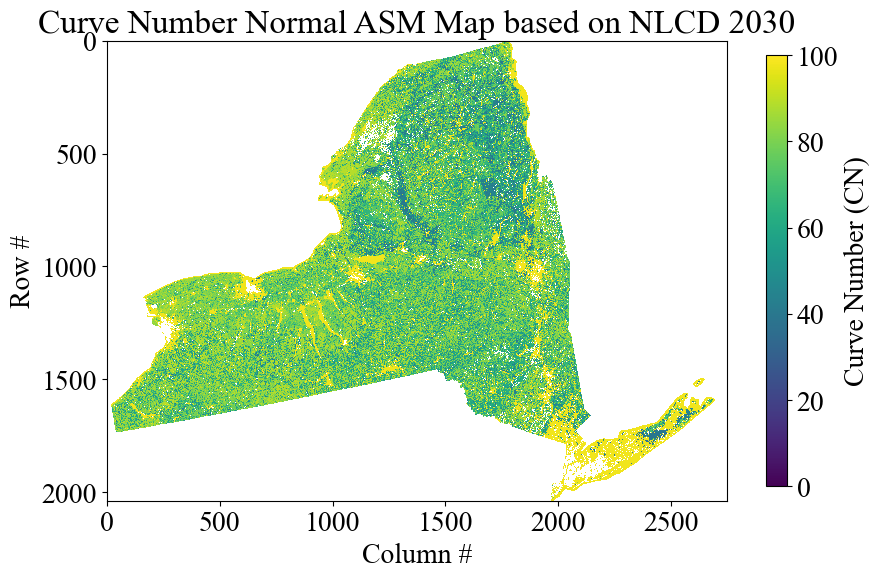

In [83]:
# Plot dry CN 
# Nodata value
no_data_value = 0
# Masking NoData values
masked_cn_map = np.ma.masked_where(cn_map == no_data_value, cn_map)
# Plotting the CN map
plt.figure(figsize=(10, 8))
plt.imshow(masked_cn_map, cmap='viridis', vmin=0, vmax=100, interpolation='nearest')
plt.colorbar(label='Curve Number (CN)',shrink=0.7)
plt.title('Curve Number Normal ASM Map based on NLCD 2030')
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.grid(False)
plt.savefig(fr'D:\culvert repo\Results\Figures\CN_map_A2_2030.png', dpi=300, bbox_inches='tight')
plt.show()

# Normal ASM

## A2

In [5]:
%%time
# Function to calculate CN based on NLCD land use and HSG
def calculate_cn(nlcd_value, hsg):
    nlcd_to_cn = {
        1: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Water
        3: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Private
        4: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Other
        2: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Developed
        7: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Barren
        8: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},  # Deciduous Forest
        9: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Evergreen Forest
        10: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Mixed Forest
        12: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},  # Shrubland
        14: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},  # Hay/Pasture Land
        13: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},  # Cropland
        16: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},  # Woody Wetland
        15: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}  # Herbaceous Wetland
    }
    return nlcd_to_cn.get(nlcd_value, {}).get(hsg, None)

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A2\CONUS_A2_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\A2\Normal\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [01:03<00:00, 32.31it/s]


CPU times: total: 8min 47s
Wall time: 9min 8s


## A1B

In [6]:
%%time

# Function to calculate CN based on NLCD land use and HSG
def calculate_cn(nlcd_value, hsg):
    nlcd_to_cn = {
        1: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Water
        3: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Private
        4: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Other
        2: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Developed
        7: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Barren
        8: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},  # Deciduous Forest
        9: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Evergreen Forest
        10: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Mixed Forest
        12: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},  # Shrubland
        14: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},  # Hay/Pasture Land
        13: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},  # Cropland
        16: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},  # Woody Wetland
        15: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}  # Herbaceous Wetland
    }
    return nlcd_to_cn.get(nlcd_value, {}).get(hsg, None)

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A1B\CONUS_A1B_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\A1B\Normal\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [01:02<00:00, 32.69it/s]

CPU times: total: 8min 48s
Wall time: 9min 9s


## B1

In [7]:
%%time

# Function to calculate CN based on NLCD land use and HSG
def calculate_cn(nlcd_value, hsg):
    nlcd_to_cn = {
        1: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Water
        3: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Private
        4: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Other
        2: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Developed
        7: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Barren
        8: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},  # Deciduous Forest
        9: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Evergreen Forest
        10: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Mixed Forest
        12: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},  # Shrubland
        14: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},  # Hay/Pasture Land
        13: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},  # Cropland
        16: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},  # Woody Wetland
        15: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}  # Herbaceous Wetland
    }
    return nlcd_to_cn.get(nlcd_value, {}).get(hsg, None)

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B1\CONUS_B1_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\B1\Normal\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [01:03<00:00, 32.09it/s]


CPU times: total: 8min 47s
Wall time: 9min 8s


## B2

In [8]:
%%time

# Function to calculate CN based on NLCD land use and HSG
def calculate_cn(nlcd_value, hsg):
    nlcd_to_cn = {
        1: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Water
        3: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Private
        4: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Other
        2: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Developed
        7: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Barren
        8: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},  # Deciduous Forest
        9: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Evergreen Forest
        10: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Mixed Forest
        12: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},  # Shrubland
        14: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},  # Hay/Pasture Land
        13: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},  # Cropland
        16: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},  # Woody Wetland
        15: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}  # Herbaceous Wetland
    }
    return nlcd_to_cn.get(nlcd_value, {}).get(hsg, None)

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B2\CONUS_B2_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\B2\Normal\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [01:03<00:00, 32.31it/s]


CPU times: total: 8min 55s
Wall time: 9min 11s


In [9]:
# Updated NLCD to CN mapping for dry and wet ASM 
nlcd_to_cn = {
    1: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Water
    3: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Private
    4: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Mechanically Disturbed Other
    2: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2},  # Developed
    7: {'A': 77, 'B': 86, 'C': 91, 'D': 94, 'A/D': (77 + 94) / 2, 'B/D': (86 + 94) / 2, 'C/D': (91 + 94) / 2},  # Barren
    8: {'A': 45, 'B': 66, 'C': 77, 'D': 83, 'A/D': (45 + 83) / 2, 'B/D': (66 + 83) / 2, 'C/D': (77 + 83) / 2},  # Deciduous Forest
    9: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Evergreen Forest
    10: {'A': 39.1, 'B': 48, 'C': 57, 'D': 63, 'A/D': (39.1 + 63) / 2, 'B/D': (48 + 63) / 2, 'C/D': (57 + 63) / 2},  # Mixed Forest
    12: {'A': 63, 'B': 77, 'C': 85, 'D': 88, 'A/D': (63 + 88) / 2, 'B/D': (77 + 88) / 2, 'C/D': (85 + 88) / 2},  # Shrubland
    14: {'A': 68.9, 'B': 71, 'C': 81, 'D': 89, 'A/D': (68.9 + 89) / 2, 'B/D': (71 + 89) / 2, 'C/D': (81 + 89) / 2},  # Hay/Pasture Land
    13: {'A': 67, 'B': 78, 'C': 85, 'D': 89, 'A/D': (67 + 89) / 2, 'B/D': (78 + 89) / 2, 'C/D': (85 + 89) / 2},  # Cropland
    16: {'A': 87.4, 'B': 89, 'C': 90.4, 'D': 90.7, 'A/D': (87.4 + 90.7) / 2, 'B/D': (89 + 90.7) / 2, 'C/D': (90.4 + 90.7) / 2},  # Woody Wetland
    15: {'A': 98, 'B': 98, 'C': 98, 'D': 98, 'A/D': (98 + 98) / 2, 'B/D': (98 + 98) / 2, 'C/D': (98 + 98) / 2}  # Herbaceous Wetland
}

# Reusing dry_factors and wet_factors from previous code
dry_factors = {
    10: 0.40,
    20: 0.45,
    30: 0.50,
    40: 0.55,
    50: 0.62,
    60: 0.67,
    70: 0.73,
    80: 0.79,
    90: 0.87,
    100: 1.00
}

wet_factors = {
    10: 2.22,
    20: 1.85,
    30: 1.67,
    40: 1.50,
    50: 1.40,
    60: 1.30,
    70: 1.21,
    80: 1.14,
    90: 1.07,
    100: 1.00
}

# Initialize dictionaries to store results
nlcd_to_cn_dry = {}
nlcd_to_cn_wet = {}

# Perform calculations
for key, value in nlcd_to_cn.items():
    for type_key in ['A', 'B', 'C', 'D', 'A/D', 'B/D', 'C/D']:
        CN = value[type_key]
        
        # Calculate dry CN
        lower_dry_CN = max(filter(lambda x: x <= CN, dry_factors))
        upper_dry_CN = min(filter(lambda x: x >= CN, dry_factors))
        
        if lower_dry_CN == upper_dry_CN:
            CN_dry = dry_factors.get(lower_dry_CN, 1.0) * CN
        else:
            lower_dry_factor = dry_factors.get(lower_dry_CN, 1.0)
            upper_dry_factor = dry_factors.get(upper_dry_CN, 1.0)
            CN_dry = (lower_dry_factor + (upper_dry_factor - lower_dry_factor) * (CN - lower_dry_CN) / (upper_dry_CN - lower_dry_CN)) * CN
        
        # Calculate wet CN
        lower_wet_CN = max(filter(lambda x: x <= CN, wet_factors))
        upper_wet_CN = min(filter(lambda x: x >= CN, wet_factors))
        
        if lower_wet_CN == upper_wet_CN:
            CN_wet = wet_factors.get(lower_wet_CN, 1.0) * CN
        else:
            lower_wet_factor = wet_factors.get(lower_wet_CN, 1.0)
            upper_wet_factor = wet_factors.get(upper_wet_CN, 1.0)
            CN_wet = (lower_wet_factor + (upper_wet_factor - lower_wet_factor) * (CN - lower_wet_CN) / (upper_wet_CN - lower_wet_CN)) * CN
        
        # Store results in dictionaries
        if key not in nlcd_to_cn_dry:
            nlcd_to_cn_dry[key] = {}
        if key not in nlcd_to_cn_wet:
            nlcd_to_cn_wet[key] = {}
        
        nlcd_to_cn_dry[key][type_key] = CN_dry
        nlcd_to_cn_wet[key][type_key] = CN_wet

print("NLCD to CN Dry:")
print(nlcd_to_cn_dry)
print("\nNLCD to CN Wet:")
print(nlcd_to_cn_wet)

NLCD to CN Dry:
{1: {'A': 95.452, 'B': 95.452, 'C': 95.452, 'D': 95.452, 'A/D': 95.452, 'B/D': 95.452, 'C/D': 95.452}, 3: {'A': 59.444, 'B': 72.068, 'C': 80.353, 'D': 86.668, 'A/D': 71.307, 'B/D': 78.3, 'C/D': 83.48125}, 4: {'A': 59.444, 'B': 72.068, 'C': 80.353, 'D': 86.668, 'A/D': 71.307, 'B/D': 78.3, 'C/D': 83.48125}, 2: {'A': 95.452, 'B': 95.452, 'C': 95.452, 'D': 95.452, 'A/D': 95.452, 'B/D': 95.452, 'C/D': 95.452}, 7: {'A': 59.444, 'B': 72.068, 'C': 80.353, 'D': 86.668, 'A/D': 71.307, 'B/D': 78.3, 'C/D': 83.48125}, 8: {'A': 26.325, 'B': 46.596, 'C': 59.444, 'D': 67.56200000000001, 'A/D': 44.416000000000004, 'B/D': 56.3965, 'C/D': 63.2}, 9: {'A': 21.329050000000006, 'B': 29.088, 'C': 37.335, 'D': 43.344, 'A/D': 31.919012499999997, 'B/D': 35.93625, 'C/D': 40.2}, 10: {'A': 21.329050000000006, 'B': 29.088, 'C': 37.335, 'D': 43.344, 'A/D': 31.919012499999997, 'B/D': 35.93625, 'C/D': 40.2}, 12: {'A': 43.344, 'B': 59.444, 'C': 70.55000000000001, 'D': 75.152, 'A/D': 57.606500000000004, '

# Dry

## A2

In [10]:
%%time

# compute the CN raster for dry conditions
# Function to calculate CN (dry) based on NLCD land use and HSG
def calculate_cn_dry(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_dry and hsg in nlcd_to_cn_dry[nlcd_value]:
        return nlcd_to_cn_dry[nlcd_value][hsg]
    else:
        return None

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A2\CONUS_A2_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_dry(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\A2\Dry\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [00:57<00:00, 35.22it/s]


CPU times: total: 8min 10s
Wall time: 8min 22s


## A1B

In [11]:
%%time

# compute the CN raster for dry conditions
# Function to calculate CN (dry) based on NLCD land use and HSG
def calculate_cn_dry(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_dry and hsg in nlcd_to_cn_dry[nlcd_value]:
        return nlcd_to_cn_dry[nlcd_value][hsg]
    else:
        return None

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A1B\CONUS_A1B_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_dry(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\A1B\Dry\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [00:57<00:00, 35.16it/s]


CPU times: total: 8min 5s
Wall time: 8min 18s


## B2

In [12]:
%%time

# compute the CN raster for dry conditions
# Function to calculate CN (dry) based on NLCD land use and HSG
def calculate_cn_dry(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_dry and hsg in nlcd_to_cn_dry[nlcd_value]:
        return nlcd_to_cn_dry[nlcd_value][hsg]
    else:
        return None

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B2\CONUS_B2_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)
        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_dry(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\B2\Dry\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)


Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [00:58<00:00, 34.80it/s]


CPU times: total: 8min 9s
Wall time: 8min 22s


## B1

In [13]:
%%time

# compute the CN raster for dry conditions
# Function to calculate CN (dry) based on NLCD land use and HSG
def calculate_cn_dry(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_dry and hsg in nlcd_to_cn_dry[nlcd_value]:
        return nlcd_to_cn_dry[nlcd_value][hsg]
    else:
        return None

# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B1\CONUS_B1_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_dry(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\B1\Dry\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)


Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [00:57<00:00, 35.65it/s]


CPU times: total: 8min 11s
Wall time: 8min 23s


# Wet

## A2

In [ ]:
%%time

# Compute the CN raster for wet ASM condition
# Function to calculate CN (wet) based on NLCD land use and HSG
def calculate_cn_wet(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_wet and hsg in nlcd_to_cn_wet[nlcd_value]:
        return nlcd_to_cn_wet[nlcd_value][hsg]
    else:
        return None
# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A2\CONUS_A2_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_wet(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\A2\Wet\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

## A1B

In [14]:
%%time

# Compute the CN raster for wet ASM condition
# Function to calculate CN (wet) based on NLCD land use and HSG
def calculate_cn_wet(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_wet and hsg in nlcd_to_cn_wet[nlcd_value]:
        return nlcd_to_cn_wet[nlcd_value][hsg]
    else:
        return None
# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\A1B\CONUS_A1B_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_wet(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\A1B\Wet\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [00:57<00:00, 35.41it/s]


CPU times: total: 8min 5s
Wall time: 8min 17s


## B2

In [15]:
%%time

# Compute the CN raster for wet ASM condition
# Function to calculate CN (wet) based on NLCD land use and HSG
def calculate_cn_wet(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_wet and hsg in nlcd_to_cn_wet[nlcd_value]:
        return nlcd_to_cn_wet[nlcd_value][hsg]
    else:
        return None
# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B2\CONUS_B2_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_wet(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\B2\Wet\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [00:57<00:00, 35.63it/s]


CPU times: total: 8min 6s
Wall time: 8min 18s


## B1

In [16]:
%%time

# Compute the CN raster for wet ASM condition
# Function to calculate CN (wet) based on NLCD land use and HSG
def calculate_cn_wet(nlcd_value, hsg):
    
    if nlcd_value in nlcd_to_cn_wet and hsg in nlcd_to_cn_wet[nlcd_value]:
        return nlcd_to_cn_wet[nlcd_value][hsg]
    else:
        return None
# Define hydrologic soil groups and corresponding letters
soil_groups = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'A/D',
    6: 'B/D',
    7: 'C/D'
}

for k in [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]:
    # Load NLCD and HSG raster data
    nlcd_file = fr"D:\culvert repo\data\initial layers\CONUS_Landcover\cliped_future_LULC\B1\CONUS_B1_y{k}_clipped.tif"
    with rasterio.open(nlcd_file) as nlcd_src, rasterio.open(hydrologic_soil_path) as hsg_src:
        nlcd_data = nlcd_src.read(1)
        hsg_data = hsg_src.read(1)

        # Mask NoData values
        nlcd_data = np.ma.masked_where(nlcd_data == 0, nlcd_data)
        hsg_data = np.ma.masked_equal(hsg_data, hsg_src.nodata)

        # Initialize CN map
        cn_map = np.zeros_like(nlcd_data, dtype=np.uint8)

        # Iterate through each row with a progress bar
        for i in tqdm(range(nlcd_data.shape[0]), desc="Processing rows"):
            for j in range(nlcd_data.shape[1]):
                if nlcd_data.mask[i, j]:  # Check if the NLCD value is masked
                    continue

                nlcd_value = int(nlcd_data[i, j])  # Ensure integer type for indexing

                # Handle specific cases for Water and Herbaceous Wetland
                if nlcd_value in {1, 15}:  # Water and Herbaceous Wetland
                    cn_map[i, j] = 98
                    continue

                # Convert NLCD pixel coordinates to geographical coordinates
                x, y = nlcd_src.xy(i, j)
                # Convert geographical coordinates to HSG pixel coordinates
                hsg_row, hsg_col = hsg_src.index(x, y)

                # Check if the HSG value is valid and not masked
                if (0 <= hsg_row < hsg_data.shape[0] and
                    0 <= hsg_col < hsg_data.shape[1] and
                    not np.ma.is_masked(hsg_data[hsg_row, hsg_col])):

                    hsg_value = int(hsg_data[hsg_row, hsg_col])  # Ensure integer type for indexing

                    if hsg_value in soil_groups:
                        hsg_type = soil_groups[hsg_value]
                        cn_value = calculate_cn_wet(nlcd_value, hsg_type)

                        if cn_value is not None:
                            cn_map[i, j] = cn_value

    # Save the CN map as a new TIFF file
    cn_map_path = fr'D:\culvert repo\Results\CN\B1\Wet\CN_Map_{k}.tif'
    # Use metadata from the NLCD file
    meta = nlcd_src.meta.copy()
    meta.update({
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0
    })
    
    with rasterio.open(cn_map_path, 'w', **meta) as dst:
        dst.write(cn_map, 1)

Processing rows: 100%|█████████████████████████████████████████████████████████████| 2039/2039 [00:58<00:00, 35.14it/s]

CPU times: total: 8min 10s
Wall time: 8min 22s


# Reproject CN raster of GEE from ESPG 4326 to 5070


In [28]:
# Define file paths
raster1_path = r"D:\culvert repo\Results\CN\CN_Map_2021.tif"
raster2_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Dry_NY.tif"
output_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Dry_NY_reprojected.tif"

# Open the reference raster (raster1) to get its CRS
src1 = gdal.Open(raster1_path)
crs1 = src1.GetProjection()

# Use gdalwarp to reproject raster2
gdal.Warp(output_path, raster2_path, dstSRS=crs1)

print(f"Reprojected raster saved to {output_path}")

Reprojected raster saved to D:\culvert repo\data\initial layers\GEE\GCN250_Dry_NY_reprojected.tif
CPU times: total: 281 ms
Wall time: 274 ms


In [29]:
# Define file paths
raster1_path = r"D:\culvert repo\Results\CN\CN_Map_2021.tif"
raster2_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Average_NY.tif"

# Open the rasters
with rasterio.open(raster1_path) as src1, rasterio.open(raster2_path) as src2:
    # Print CRS of raster1
    crs1 = src1.crs
    print(f"Coordinate System of raster1 ({raster1_path}): {crs1}")

    # Print CRS of raster2
    crs2 = src2.crs
    print(f"Coordinate System of raster2 ({raster2_path}): {crs2}")

Coordinate System of raster1 (D:\culvert repo\Results\CN\CN_Map_2021.tif): EPSG:5070
Coordinate System of raster2 (D:\culvert repo\data\initial layers\GEE\GCN250_Average_NY.tif): EPSG:4326


In [31]:
# Define file paths
raster1_path = r"D:\culvert repo\Results\CN\CN_Map_2021.tif"
raster2_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Wet_NY.tif"
output_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Wet_NY_reprojected.tif"

# Open the reference raster (raster1) to get its CRS
src1 = gdal.Open(raster1_path)
crs1 = src1.GetProjection()

# Use gdalwarp to reproject raster2
gdal.Warp(output_path, raster2_path, dstSRS=crs1)

print(f"Reprojected raster saved to {output_path}")

Reprojected raster saved to D:\culvert repo\data\initial layers\GEE\GCN250_Wet_NY_reprojected.tif


# Fill the CN map using GEE

## Normal

In [32]:

# List of directories to process
directories = [
    "D:\\culvert repo\\Results\\CN\\A1B",
    "D:\\culvert repo\\Results\\CN\\A2",
    "D:\\culvert repo\\Results\\CN\\B1",
    "D:\\culvert repo\\Results\\CN\\B2"
]

# Path to the raster that will be used to fill NoData values
fill_raster_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Average_NY.tif"

# Open the fill raster
with rasterio.open(fill_raster_path) as src2:
    data2 = src2.read(1)  # Read the first band of the fill raster
    nodata2 = src2.nodata

    for directory in directories:
        normal_dir = os.path.join(directory, "Normal")

        # Process each raster file in the Normal folder
        for filename in os.listdir(normal_dir):
            if filename.endswith(".tif"):
                raster1_path = os.path.join(normal_dir, filename)
                output_path = os.path.join(normal_dir, filename.replace(".tif", "_filled.tif"))

                # Open the raster file
                with rasterio.open(raster1_path) as src1:

                    data1 = src1.read(1)  # Read the first band
                    nodata1 = src1.nodata

                    # Get the metadata from the first raster
                    meta = src1.meta.copy()

                    # Create an empty array for the output
                    filled_data = np.copy(data1)  # Start with a copy of data1

                    # Iterate through each pixel in the first raster where the value is NoData
                    for i in tqdm(range(data1.shape[0]), desc=f"Processing {filename}"):
                        for j in range(data1.shape[1]):
                            if data1[i, j] == nodata1:
                                # Convert pixel coordinates to geographic coordinates
                                x, y = src1.xy(i, j)

                                # Convert geographic coordinates to pixel coordinates in the fill raster
                                hsg_row, hsg_col = src2.index(x, y)

                                # Check if the coordinates are within bounds of the fill raster
                                if 0 <= hsg_row < data2.shape[0] and 0 <= hsg_col < data2.shape[1]:
                                    # Get the value from the fill raster
                                    value2 = data2[hsg_row, hsg_col]
                                else:
                                    value2 = nodata2  # Use NoData if out of bounds

                                # Replace NoData value in the first raster with value from the fill raster
                                if value2 != nodata2:
                                    filled_data[i, j] = value2
                                else:
                                    filled_data[i, j] = nodata1

                    # Save the result to a new raster
                    with rasterio.open(output_path, 'w', **meta) as dst:
                        dst.write(filled_data, 1)  # Write to the first band
                        print (output_path)

Processing CN_Map_2030.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:31<00:00, 22.25it/s]


D:\culvert repo\Results\CN\A1B\Normal\CN_Map_2030_filled.tif


Processing CN_Map_2030_filled.tif: 100%|███████████████████████████████████████████| 2039/2039 [01:31<00:00, 22.29it/s]


D:\culvert repo\Results\CN\A1B\Normal\CN_Map_2030_filled_filled.tif


Processing CN_Map_2040.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:31<00:00, 22.32it/s]


...

D:\culvert repo\Results\CN\B2\Normal\CN_Map_2080_filled.tif


Processing CN_Map_2090.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:28<00:00, 23.02it/s]


D:\culvert repo\Results\CN\B2\Normal\CN_Map_2090_filled.tif


Processing CN_Map_2100.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:28<00:00, 22.96it/s]

D:\culvert repo\Results\CN\B2\Normal\CN_Map_2100_filled.tif


## Dry

In [33]:
%%time

# List of directories to process
directories = [
    "D:\\culvert repo\\Results\\CN\\A1B",
    "D:\\culvert repo\\Results\\CN\\A2",
    "D:\\culvert repo\\Results\\CN\\B1",
    "D:\\culvert repo\\Results\\CN\\B2"
]

# Path to the raster that will be used to fill NoData values
fill_raster_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Dry_NY_reprojected.tif"

# Open the fill raster
with rasterio.open(fill_raster_path) as src2:
    data2 = src2.read(1)  # Read the first band of the fill raster
    nodata2 = src2.nodata

    for directory in directories:
        normal_dir = os.path.join(directory, "Dry")

        # Process each raster file in the Normal folder
        for filename in os.listdir(normal_dir):
            if filename.endswith(".tif"):
                raster1_path = os.path.join(normal_dir, filename)
                output_path = os.path.join(normal_dir, filename.replace(".tif", "_filled.tif"))

                # Open the raster file
                with rasterio.open(raster1_path) as src1:
                    
                    print (raster1_path)

                    data1 = src1.read(1)  # Read the first band
                    nodata1 = src1.nodata

                    # Get the metadata from the first raster
                    meta = src1.meta.copy()

                    # Create an empty array for the output
                    filled_data = np.copy(data1)  # Start with a copy of data1

                    # Iterate through each pixel in the first raster where the value is NoData
                    for i in tqdm(range(data1.shape[0]), desc=f"Processing {filename}"):
                        for j in range(data1.shape[1]):
                            if data1[i, j] == nodata1:
                                # Convert pixel coordinates to geographic coordinates
                                x, y = src1.xy(i, j)

                                # Convert geographic coordinates to pixel coordinates in the fill raster
                                hsg_row, hsg_col = src2.index(x, y)

                                # Check if the coordinates are within bounds of the fill raster
                                if 0 <= hsg_row < data2.shape[0] and 0 <= hsg_col < data2.shape[1]:
                                    # Get the value from the fill raster
                                    value2 = data2[hsg_row, hsg_col]
                                else:
                                    value2 = nodata2  # Use NoData if out of bounds

                                # Replace NoData value in the first raster with value from the fill raster
                                if value2 != nodata2:
                                    filled_data[i, j] = value2
                                else:
                                    filled_data[i, j] = nodata1

                    # Save the result to a new raster
                    with rasterio.open(output_path, 'w', **meta) as dst:
                        dst.write(filled_data, 1)  # Write to the first band

D:\culvert repo\Results\CN\A1B\Dry\CN_Map_2030.tif


Processing CN_Map_2030.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:30<00:00, 22.57it/s]


D:\culvert repo\Results\CN\A1B\Dry\CN_Map_2040.tif


Processing CN_Map_2040.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:30<00:00, 22.52it/s]


D:\culvert repo\Results\CN\A1B\Dry\CN_Map_2050.tif


...

D:\culvert repo\Results\CN\B2\Dry\CN_Map_2090.tif


Processing CN_Map_2090.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:29<00:00, 22.69it/s]


D:\culvert repo\Results\CN\B2\Dry\CN_Map_2100.tif


Processing CN_Map_2100.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:30<00:00, 22.56it/s]

CPU times: total: 47min 4s
Wall time: 48min 12s


## Wet

In [34]:
%%time

# List of directories to process
directories = [
    "D:\\culvert repo\\Results\\CN\\A1B",
    "D:\\culvert repo\\Results\\CN\\A2",
    "D:\\culvert repo\\Results\\CN\\B1",
    "D:\\culvert repo\\Results\\CN\\B2"
]

# Path to the raster that will be used to fill NoData values
fill_raster_path = r"D:\\hydrological analysis\\data\\CN\\GEE\\GCN250_Wet_NY_reprojected.tif"

# Open the fill raster
with rasterio.open(fill_raster_path) as src2:
    data2 = src2.read(1)  # Read the first band of the fill raster
    nodata2 = src2.nodata

    for directory in directories:
        normal_dir = os.path.join(directory, "Wet")

        # Process each raster file in the Normal folder
        for filename in os.listdir(normal_dir):
            if filename.endswith(".tif"):
                raster1_path = os.path.join(normal_dir, filename)
                output_path = os.path.join(normal_dir, filename.replace(".tif", "_filled.tif"))

                # Open the raster file
                with rasterio.open(raster1_path) as src1:
                    
                    print (raster1_path)

                    data1 = src1.read(1)  # Read the first band
                    nodata1 = src1.nodata

                    # Get the metadata from the first raster
                    meta = src1.meta.copy()

                    # Create an empty array for the output
                    filled_data = np.copy(data1)  # Start with a copy of data1

                    # Iterate through each pixel in the first raster where the value is NoData
                    for i in tqdm(range(data1.shape[0]), desc=f"Processing {filename}"):
                        for j in range(data1.shape[1]):
                            if data1[i, j] == nodata1:
                                # Convert pixel coordinates to geographic coordinates
                                x, y = src1.xy(i, j)

                                # Convert geographic coordinates to pixel coordinates in the fill raster
                                hsg_row, hsg_col = src2.index(x, y)

                                # Check if the coordinates are within bounds of the fill raster
                                if 0 <= hsg_row < data2.shape[0] and 0 <= hsg_col < data2.shape[1]:
                                    # Get the value from the fill raster
                                    value2 = data2[hsg_row, hsg_col]
                                else:
                                    value2 = nodata2  # Use NoData if out of bounds

                                # Replace NoData value in the first raster with value from the fill raster
                                if value2 != nodata2:
                                    filled_data[i, j] = value2
                                else:
                                    filled_data[i, j] = nodata1

                    # Save the result to a new raster
                    with rasterio.open(output_path, 'w', **meta) as dst:
                        dst.write(filled_data, 1)  # Write to the first band

D:\culvert repo\Results\CN\A1B\Wet\CN_Map_2030.tif


Processing CN_Map_2030.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:30<00:00, 22.49it/s]


D:\culvert repo\Results\CN\A1B\Wet\CN_Map_2040.tif


Processing CN_Map_2040.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:30<00:00, 22.61it/s]


D:\culvert repo\Results\CN\A1B\Wet\CN_Map_2050.tif


...

D:\culvert repo\Results\CN\B2\Wet\CN_Map_2090.tif


Processing CN_Map_2090.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:30<00:00, 22.65it/s]


D:\culvert repo\Results\CN\B2\Wet\CN_Map_2100.tif


Processing CN_Map_2100.tif: 100%|██████████████████████████████████████████████████| 2039/2039 [01:30<00:00, 22.62it/s]

CPU times: total: 45min 40s
Wall time: 46min 44s


# Fill 2021 Landuse

## Normal

In [35]:
%%time

# Path to the fill raster
fill_raster_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Average_NY_reprojected.tif"

# Path to the new raster to be processed
raster_to_fill_path = r"D:\culvert repo\Results\CN\CN_Map_2021.tif"
output_path = raster_to_fill_path.replace(".tif", "_filled.tif")

# Open the fill raster
with rasterio.open(fill_raster_path) as src2:
    data2 = src2.read(1)  # Read the first band of the fill raster
    nodata2 = src2.nodata

    # Open the raster to be processed
    with rasterio.open(raster_to_fill_path) as src1:
        print(raster_to_fill_path)

        data1 = src1.read(1)  # Read the first band
        nodata1 = src1.nodata

        # Get the metadata from the first raster
        meta = src1.meta.copy()

        # Create an empty array for the output
        filled_data = np.copy(data1)  # Start with a copy of data1

        # Iterate through each pixel in the first raster where the value is NoData
        for i in tqdm(range(data1.shape[0]), desc=f"Processing {os.path.basename(raster_to_fill_path)}"):
            for j in range(data1.shape[1]):
                if data1[i, j] == nodata1:
                    # Convert pixel coordinates to geographic coordinates
                    x, y = src1.xy(i, j)

                    # Convert geographic coordinates to pixel coordinates in the fill raster
                    hsg_row, hsg_col = src2.index(x, y)

                    # Check if the coordinates are within bounds of the fill raster
                    if 0 <= hsg_row < data2.shape[0] and 0 <= hsg_col < data2.shape[1]:
                        # Get the value from the fill raster
                        value2 = data2[hsg_row, hsg_col]
                    else:
                        value2 = nodata2  # Use NoData if out of bounds

                    # Replace NoData value in the first raster with value from the fill raster
                    if value2 != nodata2:
                        filled_data[i, j] = value2
                    else:
                        filled_data[i, j] = nodata1

        # Save the result to a new raster
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(filled_data, 1)  # Write to the first band

D:\culvert repo\Results\CN\CN_Map_2021.tif


Processing CN_Map_2021.tif: 100%|██████████████████████████████████████████████| 21407/21407 [2:43:09<00:00,  2.19it/s]


CPU times: total: 2h 39min 21s
Wall time: 2h 43min 18s


## Wet

In [36]:
%%time

# Path to the fill raster
fill_raster_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Wet_NY_reprojected.tif"

# Path to the new raster to be processed
raster_to_fill_path = r"D:\culvert repo\Results\CN\CN_Map_wet_2021.tif"
output_path = raster_to_fill_path.replace(".tif", "_filled.tif")

# Open the fill raster
with rasterio.open(fill_raster_path) as src2:
    data2 = src2.read(1)  # Read the first band of the fill raster
    nodata2 = src2.nodata

    # Open the raster to be processed
    with rasterio.open(raster_to_fill_path) as src1:
        print(raster_to_fill_path)

        data1 = src1.read(1)  # Read the first band
        nodata1 = src1.nodata

        # Get the metadata from the first raster
        meta = src1.meta.copy()

        # Create an empty array for the output
        filled_data = np.copy(data1)  # Start with a copy of data1

        # Iterate through each pixel in the first raster where the value is NoData
        for i in tqdm(range(data1.shape[0]), desc=f"Processing {os.path.basename(raster_to_fill_path)}"):
            for j in range(data1.shape[1]):
                if data1[i, j] == nodata1:
                    # Convert pixel coordinates to geographic coordinates
                    x, y = src1.xy(i, j)

                    # Convert geographic coordinates to pixel coordinates in the fill raster
                    hsg_row, hsg_col = src2.index(x, y)

                    # Check if the coordinates are within bounds of the fill raster
                    if 0 <= hsg_row < data2.shape[0] and 0 <= hsg_col < data2.shape[1]:
                        # Get the value from the fill raster
                        value2 = data2[hsg_row, hsg_col]
                    else:
                        value2 = nodata2  # Use NoData if out of bounds

                    # Replace NoData value in the first raster with value from the fill raster
                    if value2 != nodata2:
                        filled_data[i, j] = value2
                    else:
                        filled_data[i, j] = nodata1

        # Save the result to a new raster
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(filled_data, 1)  # Write to the first band

D:\culvert repo\Results\CN\CN_Map_wet_2021.tif


Processing CN_Map_wet_2021.tif: 100%|██████████████████████████████████████████| 21407/21407 [2:41:12<00:00,  2.21it/s]


CPU times: total: 2h 37min 33s
Wall time: 2h 41min 23s


## Dry

In [37]:
%%time

# Path to the fill raster
fill_raster_path = r"D:\culvert repo\data\initial layers\GEE\GCN250_Dry_NY_reprojected.tif"

# Path to the new raster to be processed
raster_to_fill_path = r"D:\culvert repo\Results\CN\CN_Map_dry_2021.tif"
output_path = raster_to_fill_path.replace(".tif", "_filled.tif")

# Open the fill raster
with rasterio.open(fill_raster_path) as src2:
    data2 = src2.read(1)  # Read the first band of the fill raster
    nodata2 = src2.nodata

    # Open the raster to be processed
    with rasterio.open(raster_to_fill_path) as src1:
        print(raster_to_fill_path)

        data1 = src1.read(1)  # Read the first band
        nodata1 = src1.nodata

        # Get the metadata from the first raster
        meta = src1.meta.copy()

        # Create an empty array for the output
        filled_data = np.copy(data1)  # Start with a copy of data1

        # Iterate through each pixel in the first raster where the value is NoData
        for i in tqdm(range(data1.shape[0]), desc=f"Processing {os.path.basename(raster_to_fill_path)}"):
            for j in range(data1.shape[1]):
                if data1[i, j] == nodata1:
                    # Convert pixel coordinates to geographic coordinates
                    x, y = src1.xy(i, j)

                    # Convert geographic coordinates to pixel coordinates in the fill raster
                    hsg_row, hsg_col = src2.index(x, y)

                    # Check if the coordinates are within bounds of the fill raster
                    if 0 <= hsg_row < data2.shape[0] and 0 <= hsg_col < data2.shape[1]:
                        # Get the value from the fill raster
                        value2 = data2[hsg_row, hsg_col]
                    else:
                        value2 = nodata2  # Use NoData if out of bounds

                    # Replace NoData value in the first raster with value from the fill raster
                    if value2 != nodata2:
                        filled_data[i, j] = value2
                    else:
                        filled_data[i, j] = nodata1

        # Save the result to a new raster
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(filled_data, 1)  # Write to the first band

D:\culvert repo\Results\CN\CN_Map_dry_2021.tif


Processing CN_Map_dry_2021.tif: 100%|██████████████████████████████████████████| 21407/21407 [2:41:04<00:00,  2.22it/s]


CPU times: total: 2h 37min 23s
Wall time: 2h 41min 16s


# plot the CN

In [ ]:
# Path to the TIFF file
tif_path = r'D:\culvert repo\Results\CN\A2\Normal\CN_Map_2030_filled.tif'

# Set font properties globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Set the font size larger

# Open the TIFF file
with rasterio.open(tif_path) as src:
    # Read the data
    cn_map = src.read(1)  # Read the first band

# Define the NoData value
no_data_value = src.nodata

# Masking NoData values
masked_cn_map = np.ma.masked_where(cn_map == no_data_value, cn_map)

# Reverse the RdYlGn colormap
cmap = plt.get_cmap('RdYlGn').reversed()

# Plotting the CN map
plt.figure(figsize=(10, 8))
plt.imshow(masked_cn_map, cmap=cmap, vmin=39, vmax=100, interpolation='nearest')
plt.colorbar(label='Curve Number (CN)',shrink=0.8)
plt.title('Curve Number (2030) Map under A2 scenario')
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.grid(False)
plt.savefig(r'D:\culvert repo\Results\Figures\CN_map_A2_2030.png', dpi=300, bbox_inches='tight')
plt.show()

# 2021 CN map

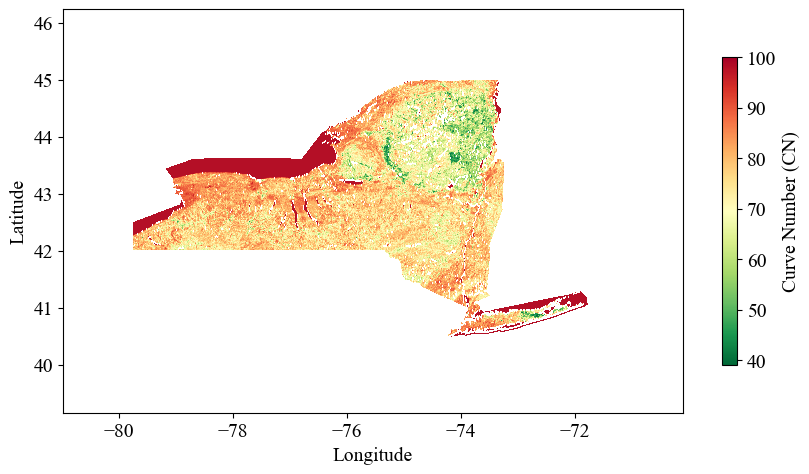

In [21]:
# Path to the TIFF file
src_path = r'D:\culvert repo\Results\CN\CN_Map_2021_filled.tif'
# Set font properties globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Set the font size larger
# Open the TIFF file
with rasterio.open(src_path) as src:
    # Define target CRS (EPSG:4326)
    dst_crs = 'EPSG:4326'
    # Calculate transform and shape for reprojected raster
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    # Set metadata for destination
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })
    # Prepare destination array
    dst_array = np.empty((height, width), dtype=src.meta['dtype'])

    # Reproject
    reproject(
        source=rasterio.band(src, 1),
        destination=dst_array,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
# Mask NoData values
masked_array = np.ma.masked_where(dst_array == src.nodata, dst_array)
# Get extent from new transform
xmin = transform[2]
xmax = xmin + transform[0] * dst_array.shape[1]
ymax = transform[5]
ymin = ymax + transform[4] * dst_array.shape[0]
# Plot
plt.figure(figsize=(10, 8))
cmap = plt.get_cmap('RdYlGn').reversed()
plt.imshow(masked_array, cmap=cmap, vmin=39, vmax=100,
           extent=(xmin, xmax, ymin, ymax), origin='upper')
plt.colorbar(label='Curve Number (CN)', shrink=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.savefig(r'D:\culvert repo\Results\Figures\CN_Map_2021_EPSG4326.png', dpi=300, bbox_inches='tight')
plt.show()

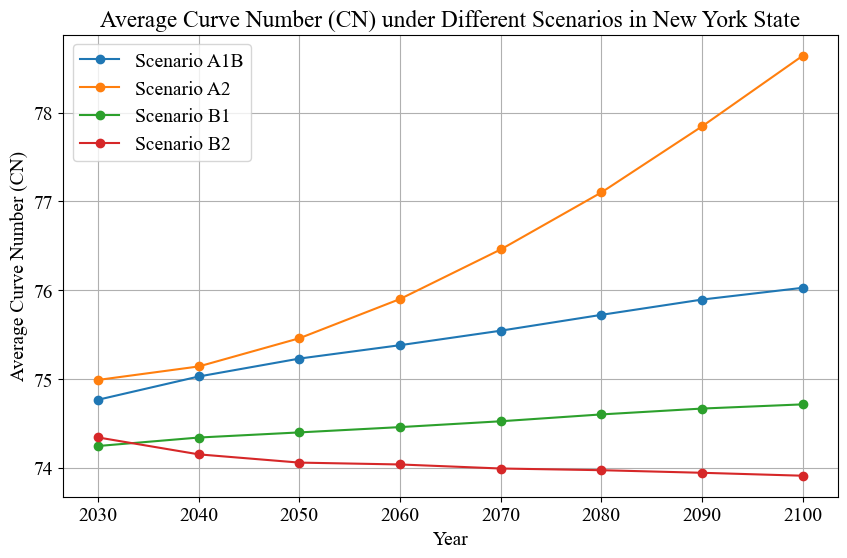

Average CN plot for all scenarios has been generated and saved.


In [39]:
# plot the CN under the four scenarios together
# Set font properties globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Set the font size larger

# Scenarios and directories
scenarios = ['A1B', 'A2', 'B1', 'B2']
base_input_dir = r'D:\culvert repo\Results\CN'

# Initialize a dictionary to store years and average CN values for each scenario
average_cn_values_scenarios = {scenario: [] for scenario in scenarios}

# Initialize a list for years
years = list(range(2030, 2101, 10))

# Loop through each scenario
for scenario in scenarios:
    input_dir = os.path.join(base_input_dir, scenario, 'Normal')
    output_dir = os.path.join(input_dir, 'Figure')

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Initialize a list to store average CN values for the current scenario
    average_cn_values = []

    # Loop through the years from 2030 to 2100
    for year in years:
        file_name = f'CN_Map_{year}_filled.tif'
        tif_path = os.path.join(input_dir, file_name)

        if os.path.exists(tif_path):
            # Open the TIFF file
            with rasterio.open(tif_path) as src:
                # Read the data
                cn_map = src.read(1)  # Read the first band

                # Define the NoData value
                no_data_value = src.nodata

                # Masking NoData values
                masked_cn_map = np.ma.masked_where(cn_map == no_data_value, cn_map)

                # Calculate the average CN value, ignoring the masked (NoData) areas
                average_cn = masked_cn_map.mean()
                
                # Store the average CN value
                average_cn_values.append(average_cn)
        else:
            print(f'File {tif_path} does not exist.')
            average_cn_values.append(np.nan)  # Append NaN for missing data

    # Store the average CN values for the current scenario
    average_cn_values_scenarios[scenario] = average_cn_values

# Plotting the average CN values over the years for all scenarios
plt.figure(figsize=(10, 6))

# Plot each scenario's average CN values
for scenario in scenarios:
    plt.plot(years, average_cn_values_scenarios[scenario], marker='o', linestyle='-', label=f'Scenario {scenario}')

plt.title('Average Curve Number (CN) under Different Scenarios in New York State')
plt.xlabel('Year')
plt.ylabel('Average Curve Number (CN)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(base_input_dir, 'average_CN_over_years_all_scenarios.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Average CN plot for all scenarios has been generated and saved.')

In [40]:
#Getting the current date and time
current_datetime = datetime.now()

# Printing the date and time
print("Date and Time of the Notebook Analysis:", current_datetime)

Date and Time of the Notebook Analysis: 2025-02-20 01:48:06.273749


In [41]:
%load_ext watermark
# Print the Python version and some dependencies
%watermark -v -m -p whitebox,numpy,pandas,geopandas,matplotlib,rasterio

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.20.0

whitebox  : 2.3.5
numpy     : 2.0.2
pandas    : 2.2.2
geopandas : 1.0.1
matplotlib: 3.8.4
rasterio  : 1.3.10

Compiler    : MSC v.1940 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 24
Architecture: 64bit

